# Deep06. Transformer 기반 한국어 챗봇

## 루브릭

| 평가문항 | 상세기준 |
|---|---|
| 1. 챗봇 훈련데이터 전처리 과정이 체계적으로 진행되었는가? | 챗봇 훈련데이터를 위한 전처리와 augmentation이 적절히 수행되어 3만개 가량의 훈련데이터셋이 구축되었다. |
| 2. transformer 모델을 활용한 챗봇 모델이 과적합을 피해 안정적으로 훈련되었는가? | 과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다. |
| 3. 챗봇이 사용자의 질문에 그럴듯한 형태로 답하는 사례가 있는가? | 주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다. |

## 진행 순서

```
 1. 라이브러리 및 환경 설정
 2. 데이터 다운로드 및 EDA
 3. 데이터 정제            — preprocess_sentence()
 4. 데이터 토큰화          — build_corpus() : Mecab 형태소 · 길이 필터 · (Q, A) 쌍 중복 제거 → 답변 단위 train/val 분할
 5. Lexical Substitution  — 질문만 증강 : ko.bin(Word2Vec) 품사 제한 치환 + 오타 노이즈 (train 만, 약 ×3)
 6. 데이터 벡터화          — <start>/<end> 부착 · 단어 사전 · 패딩 · DataLoader
 7. 훈련                  — Transformer (project_3) + run_experiment()
 8. 성능 평가              — loss · val BLEU · distinct-2 곡선 · 체크포인트(loss/BLEU 기준) 비교 · beam · 예문 답변
 9. 결과 해석
10. 실험                  — 하나씩 진행하며 기록
11. 회고
```

## 실행 플로우

```
[ 원본 ]  ChatbotData.csv  (Q, A, label)  11,823 쌍
                 |
                 v
[ 3 ]  preprocess_sentence : 소문자 · [^가-힣a-z0-9?.!,] 제거 · 공백 축소
                 |
                 v
[ 4 ]  Mecab morphs -> 길이 <= MAX_LEN -> (Q, A) 쌍 중복 제거
                 |
                 v
       train / val = 90 : 10   (답변 단위 분할 -> val 답변은 train 에 없음 · 증강 전에 분할)
                 |
                 v
[ 5 ]  (train 만) 원본 + (LS(Q), A) + (오타(Q), A)   — 답변(디코더 정답)은 바꾸지 않는다
       LS = 내용어만 · 같은 품사 · train 코퍼스에 있는 유사어(상위 3개 중 무작위)로 치환
                 |
                 v
[ 6 ]  답변에 <start>/<end> -> 단어 사전(train) -> id -> 패딩 -> DataLoader
                 |
                 v
[ 7 ]  Transformer(shared emb/fc) · warmup LR · epoch 마다 train/val loss · val BLEU · distinct-2 + 예문 답변
                 |
                 v
[ 8 ]  val loss 기준 / val BLEU 기준 체크포인트 -> 지표 비교 · beam search · 예문 답변
```

---
# 1. 라이브러리 및 환경 설정

### 1-1. 라이브러리 · 경로 · 시드

In [1]:
import os
import re
import json
import math
import time
import random
import pickle
import logging
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from tqdm.notebook import tqdm
import matplotlib
import matplotlib.pyplot as plt

# 경로 (노트북 폴더 기준 상대경로)
DATA_DIR = './data'
CSV_PATH = os.path.join(DATA_DIR, 'ChatbotData.csv')
W2V_PATH = os.path.join(DATA_DIR, 'ko', 'ko.bin')     # Kyubyong/wordvectors 한국어 Word2Vec
CKPT_DIR = os.path.join(DATA_DIR, 'ckpt')             # 실험별 best 체크포인트
HIST_DIR = os.path.join(DATA_DIR, 'history')          # 실험별 학습 기록(json)
for d in (DATA_DIR, CKPT_DIR, HIST_DIR):
    os.makedirs(d, exist_ok=True)

SEED = 42

def set_seed(seed=SEED):
    """실험마다 같은 조건에서 시작하도록 모든 난수 시드를 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('device :', device)

device : cuda


### 1-2. matplotlib 한글 폰트

In [2]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

### 1-3. nltk BLEU 패치

In [3]:
# nltk 3.6.7 + Python 3.12 호환 패치
import fractions
import nltk.translate.bleu_score as _bleu

class _RawFraction(fractions.Fraction):
    def __new__(cls, numerator=0, denominator=None, _normalize=True):
        self = super().__new__(cls, numerator, denominator)
        self._raw = None if _normalize else (numerator, denominator)
        return self

    @property
    def numerator(self):
        return self._raw[0] if self._raw else super().numerator

    @property
    def denominator(self):
        return self._raw[1] if self._raw else super().denominator

_bleu.Fraction = _RawFraction

### 1-5. 한국어 형태소 분석기 (Mecab)

Windows에서는 `konlpy.tag.Mecab`이 MeCab 바이너리를 찾지 못한다. **MeCab-ko 엔진 + mecab-ko-dic**인 `mecab_ko`로 우회한다.

In [4]:
def get_ko_tokenizer():
    """한국어 형태소 분석기를 확보하고 (morphs 함수, 이름) 을 돌려준다.

    Windows 에서는 MeCab 바이너리를 찾지 못해 실패하는 경우가 많다.
    아래 순서로 시도하고, 성공한 경로를 이름과 함께 반환한다.

        1) konlpy.tag.Mecab   : 명세가 요구하는 1순위
        2) mecab_ko           : 같은 MeCab-ko 엔진. konlpy 래퍼만 우회한다
        3) kiwipiepy.Kiwi     : 이미 설치되어 있는 최후 보루
    """
    # ---- 1) KoNLPy Mecab ----
    try:
        from konlpy.tag import Mecab
        tagger = Mecab()
        tagger.morphs('테스트')
        return tagger.morphs, 'konlpy.tag.Mecab'
    except Exception as e:
        print(f'[1] konlpy.tag.Mecab  사용 불가 -> {type(e).__name__}: {e}')

    # ---- 2) mecab-ko 패키지 직접 사용 ----
    try:
        import mecab_ko
        try:
            tagger = mecab_ko.MeCab()
            tagger.morphs('테스트')
            return tagger.morphs, 'mecab_ko.MeCab'
        except AttributeError:
            pass

        try:
            tagger = mecab_ko.Tagger()
        except Exception:
            import mecab_ko_dic
            tagger = mecab_ko.Tagger(mecab_ko_dic.MECAB_ARGS)

        def morphs(text):
            # parse() 는 "표층형\t품사정보" 줄들을 내놓고 마지막에 EOS 가 붙는다.
            return [line.split('\t')[0] for line in tagger.parse(text).splitlines()
                    if line and line != 'EOS']

        morphs('테스트')
        return morphs, 'mecab_ko.Tagger'
    except Exception as e:
        print(f'[2] mecab_ko          사용 불가 -> {type(e).__name__}: {e}')

    # ---- 3) Kiwi ----
    try:
        from kiwipiepy import Kiwi
        kiwi = Kiwi()

        def morphs(text):
            return [t.form for t in kiwi.tokenize(text)]

        morphs('테스트')
        return morphs, 'kiwipiepy.Kiwi'
    except Exception as e:
        print(f'[3] kiwipiepy.Kiwi    사용 불가 -> {type(e).__name__}: {e}')

    raise RuntimeError('사용 가능한 형태소 분석기가 없습니다. pip install mecab-ko mecab-ko-dic')


ko_morphs, TOKENIZER_NAME = get_ko_tokenizer()
print('>> 사용 분석기 :', TOKENIZER_NAME)
print(ko_morphs('오늘 일찍 일어났더니 피곤하다.'))

[1] konlpy.tag.Mecab  사용 불가 -> Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/
>> 사용 분석기 : mecab_ko.Tagger
['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']


---
# 2. 데이터 다운로드 및 EDA

### 2-1. 데이터 다운로드

`ChatbotData.csv`를 읽어 질문과 답변을 각각 `questions`, `answers`에 저장한다.

In [5]:
CSV_URL = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'

if os.path.exists(CSV_PATH):
    print('데이터가 이미 있습니다:', CSV_PATH)
else:
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)
    print('다운로드 완료:', CSV_PATH)

df = pd.read_csv(CSV_PATH)
questions = df['Q'].tolist()
answers = df['A'].tolist()

print('shape :', df.shape)
df.head()

다운로드 완료: ./data\ChatbotData.csv
shape : (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


### 2-2. 결측치 · label 분포 · 중복 확인

In [6]:
print('결측치 :', df.isnull().sum().to_dict())
print('label  :', df['label'].value_counts().sort_index().to_dict(), ' (0: 일상, 1: 이별(부정), 2: 사랑(긍정))')
print()
print(f'전체 쌍      : {len(df):,}')
print(f'고유 질문    : {df["Q"].nunique():,}')
print(f'고유 답변    : {df["A"].nunique():,}')
print(f'고유 (Q, A)  : {len(df.drop_duplicates(["Q", "A"])):,}')

결측치 : {'Q': 0, 'A': 0, 'label': 0}
label  : {0: 5290, 1: 3570, 2: 2963}  (0: 일상, 1: 이별(부정), 2: 사랑(긍정))

전체 쌍      : 11,823
고유 질문    : 11,662
고유 답변    : 7,779
고유 (Q, A)  : 11,750


### 2-3. 문자 종류

In [7]:
KEEP_PUNCT = set('?.!,')

def char_type(ch):
    if '가' <= ch <= '힣':
        return '완성형 한글'
    if 'ㄱ' <= ch <= 'ㅣ':
        return '한글 자모'
    if ch.isascii() and ch.isalpha():
        return '라틴 문자'
    if ch.isdigit():
        return '숫자'
    if ch in KEEP_PUNCT:
        return '?.!,'
    if ch.isspace():
        return '공백'
    return '기타 기호'

char_counter = Counter(char_type(ch) for s in questions + answers for ch in s)
total_chars = sum(char_counter.values())
for k, v in char_counter.most_common():
    print(f'{k:8s} {v:8,}  ({v / total_chars:6.2%})')

# 지워질 문자 중 자주 나오는 것
removed = Counter(ch for s in questions + answers for ch in s
                  if char_type(ch) in ('한글 자모', '기타 기호'))
print('\n제거 대상 상위 20 :', removed.most_common(20))

완성형 한글    250,250  (75.88%)
공백         62,438  (18.93%)
?.!,       16,230  ( 4.92%)
숫자            535  ( 0.16%)
한글 자모         131  ( 0.04%)
라틴 문자         128  ( 0.04%)
기타 기호          81  ( 0.02%)

제거 대상 상위 20 : [('ㅠ', 74), ('~', 55), ('ㅎ', 23), ('ㅜ', 21), ('ㅋ', 12), ("'", 9), (';', 6), ('…', 5), ('-', 3), ('%', 2), ('_', 1), ('ㅊ', 1)]


### 2-4. 형태소 길이 분포

길이 컷(`MAX_LEN`)을 정하기 위해 원문을 Mecab으로 쪼갠 길이를 확인한다.

Q morphs:   0%|          | 0/11823 [00:00<?, ?it/s]

A morphs:   0%|          | 0/11823 [00:00<?, ?it/s]

질문 : mean  7.03 | median 6 | p90 12 | p99 18 | max 32
답변 : mean  8.38 | median 8 | p90 13 | p99 20 | max 40
길이 컷 15 -> 잔존 93.28%
길이 컷 20 -> 잔존 98.66%
길이 컷 25 -> 잔존 99.70%


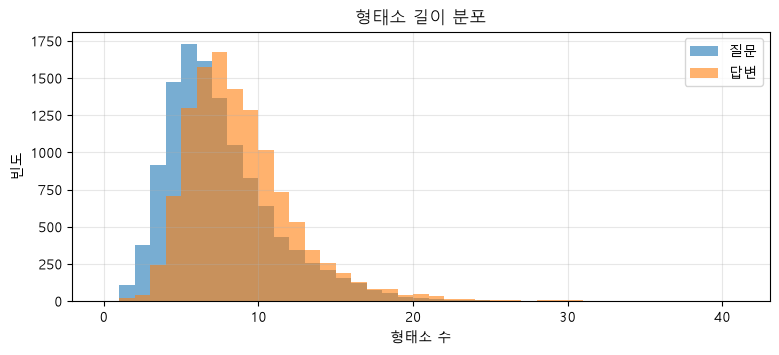

In [8]:
q_len = np.array([len(ko_morphs(s)) for s in tqdm(questions, desc='Q morphs')])
a_len = np.array([len(ko_morphs(s)) for s in tqdm(answers, desc='A morphs')])

for name, arr in (('질문', q_len), ('답변', a_len)):
    p50, p90, p99 = np.percentile(arr, [50, 90, 99])
    print(f'{name} : mean {arr.mean():5.2f} | median {p50:.0f} | p90 {p90:.0f} | p99 {p99:.0f} | max {arr.max()}')

for cut in (15, 20, 25):
    keep = ((q_len <= cut) & (a_len <= cut)).mean()
    print(f'길이 컷 {cut} -> 잔존 {keep:.2%}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(q_len, bins=range(0, 42), alpha=.6, label='질문')
ax.hist(a_len, bins=range(0, 42), alpha=.6, label='답변')
ax.set_xlabel('형태소 수'); ax.set_ylabel('빈도'); ax.set_title('형태소 길이 분포')
ax.legend(); ax.grid(alpha=.3)
plt.show()

### 2-5. EDA 정리

| 확인 항목 | 실행 결과 | 반영 |
|---|---|---|
| 형태소 분석기 | mecab_ko.Tagger | - |
| 결측치 / label | 결측치 없음. 일상(0): 5290, 이별(1): 3570, 사랑(2): 2963 | - |
| 중복 | 고유 Q: 11,662 / 고유 A: 7,779 / 고유 (Q, A): 11,750 | (Q, A) 쌍 중복 제거 · 답변 단위 분할 |
| 문자 종류 | 완성형 한글 (75.88%) / 주요 특수문자 (4.92%) / 숫자 (0.16%) / 한글 자모 (0.04%) / 라틴 문자 (0.04%) / 기타 (0.02%) | 정제 규칙 |
| 길이 | 20 | `MAX_LEN` |

---
# 3. 데이터 정제

`preprocess_sentence()` 조건

1. 영문자는 **모두 소문자**로 변환한다.
2. 영문자·한글·숫자·주요 특수문자(`? . ! ,`)를 제외하고 **정규식으로 모두 제거**한다.

In [9]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()                                 # 영문 소문자화
    sentence = re.sub(r'[^가-힣a-z0-9?.!,]+', ' ', sentence)    # 허용 문자 외 제거
    sentence = re.sub(r' {2,}', ' ', sentence)                  # 다중 공백 축소
    return sentence.strip()

In [10]:
# 정제 후 빈 문장이 되는 경우 확인
empty_q = sum(1 for s in questions if not preprocess_sentence(s))
empty_a = sum(1 for s in answers if not preprocess_sentence(s))
print(f'정제 후 빈 질문 {empty_q}건 / 빈 답변 {empty_a}건')

정제 후 빈 질문 0건 / 빈 답변 0건


---
# 4. 데이터 토큰화

`build_corpus()` 조건

1. 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받는다.
2. `preprocess_sentence()`로 정제하고 토큰화한다.
3. 토큰화는 전달받은 토크나이즈 함수(`ko_morphs`)를 사용한다.
4. 토큰 수가 `MAX_LEN`을 넘는 문장은 제외한다.
5. 중복을 제외한다. **질문과 답변이 모두 같은 (Q, A) 쌍만** 제외한다.

In [104]:
MAX_LEN = 20

def build_corpus(src_sentences, tgt_sentences, tokenize_fn, max_len=MAX_LEN):
    """정제 -> 토큰화 -> 길이 필터 -> (소스, 타겟) 쌍 중복 제거."""
    que_corpus, ans_corpus = [], []
    seen_pairs = set()
    stats = Counter()

    for src, tgt in zip(src_sentences, tgt_sentences):
        src_tokens = tokenize_fn(preprocess_sentence(src))
        tgt_tokens = tokenize_fn(preprocess_sentence(tgt))

        if not src_tokens or not tgt_tokens:
            stats['빈 문장'] += 1
            continue
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            stats['길이 초과'] += 1
            continue

        # 질문·답변이 모두 같은 쌍만 중복으로 본다. 같은 답변을 가진 다른 질문은 남긴다.
        pair_key = (' '.join(src_tokens), ' '.join(tgt_tokens))
        if pair_key in seen_pairs:
            stats['쌍 중복'] += 1
            continue

        seen_pairs.add(pair_key)
        que_corpus.append(src_tokens)
        ans_corpus.append(tgt_tokens)

    return que_corpus, ans_corpus, stats


que_corpus, ans_corpus, corpus_stats = build_corpus(questions, answers, ko_morphs)

print(f'원본 {len(questions):,} 쌍 -> 남은 쌍 {len(que_corpus):,}')
for k, v in corpus_stats.items():
    print(f'  제외 - {k}: {v:,}')
for q, a in list(zip(que_corpus, ans_corpus))[:5]:
    print(q, '->', a)

원본 11,823 쌍 -> 남은 쌍 11,590
  제외 - 길이 초과: 158
  제외 - 쌍 중복: 75
['12', '시', '땡', '!'] -> ['하루', '가', '또', '가', '네요', '.']
['1', '지망', '학교', '떨어졌', '어'] -> ['위로', '해', '드립니다', '.']
['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다'] -> ['여행', '은', '언제나', '좋', '죠', '.']
['3', '박', '4', '일', '정도', '놀', '러', '가', '고', '싶', '다'] -> ['여행', '은', '언제나', '좋', '죠', '.']
['ppl', '심하', '네'] -> ['눈살', '이', '찌푸려', '지', '죠', '.']


### 4-2. train / val 분할

같은 답변을 가진 쌍은 모두 train 또는 모두 val로 보낸다. 같은 답변이 train과 val에 나뉘면 이미 외운 답변으로 평가하게 되어 val 지표가 실제보다 좋게 나온다.

In [105]:
VAL_RATIO = 0.1

# 답변 -> 그 답변을 가진 쌍 인덱스. 같은 답변은 train 과 val 에 나뉘지 않도록 그룹째 보낸다.
answer_groups = {}
for i, a in enumerate(ans_corpus):
    answer_groups.setdefault(' '.join(a), []).append(i)
groups = list(answer_groups.values())
random.Random(SEED).shuffle(groups)

n_val = int(len(que_corpus) * VAL_RATIO)
val_idx, train_idx = [], []
for g in groups:
    (val_idx if len(val_idx) < n_val else train_idx).extend(g)

train_que = [que_corpus[i] for i in train_idx]
train_ans = [ans_corpus[i] for i in train_idx]
val_que = [que_corpus[i] for i in val_idx]
val_ans = [ans_corpus[i] for i in val_idx]

shared = set(map(tuple, train_ans)) & set(map(tuple, val_ans))
print(f'답변 그룹 {len(groups):,}개 | train {len(train_que):,} 쌍 | val {len(val_que):,} 쌍 | train·val 공유 답변 {len(shared)}개')

답변 그룹 7,612개 | train 10,430 쌍 | val 1,160 쌍 | train·val 공유 답변 0개


---
# 5. Lexical Substitution (+ 오타 노이즈)

- **Lexical Substitution**: 사전학습 임베딩 [Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors)의 `Korean (w)` → `ko.bin`(Word2Vec, 200차원) 유사어로 치환한다.
- **오타 노이즈**: 질문에 음절 오타를 넣은 묶음을 하나 더한다.
- 증강은 **질문에만** 한다. 답변은 디코더 정답이라 치환된 답변을 넣으면 깨진 문장을 생성하도록 학습된다.

### 5-1. `ko.bin` 로드

`ko.bin`은 2016년 gensim 0.x로 저장된 **Python 2 pickle**이라 gensim 4.x의 `Word2Vec.load()`는
`'Word2Vec' object has no attribute 'wv'`로 실패한다.
그래서 pickle을 직접 풀어(`encoding='latin1'`) 단어 목록(`index2word`)과 벡터(`syn0`)만 꺼내 새 `KeyedVectors`에 담는다.

In [106]:
from gensim.models import KeyedVectors

def load_ko_w2v(path):
    """구버전 gensim Word2Vec pickle -> gensim 4.x KeyedVectors"""
    with open(path, 'rb') as f:
        old_model = pickle.load(f, encoding='latin1')   # Python 2 pickle 의 bytes/ndarray 복원
    words = old_model.__dict__['index2word']
    vectors = old_model.__dict__['syn0']

    wv = KeyedVectors(vectors.shape[1])
    wv.add_vectors(words, vectors)
    return wv


wv = load_ko_w2v(W2V_PATH)
print(f'단어 수 {len(wv.index_to_key):,} | 차원 {wv.vector_size}')
wv.most_similar('피곤')

단어 수 30,185 | 차원 200


[('지루', 0.6597292423248291),
 ('거만', 0.6573756337165833),
 ('조용', 0.6500644087791443),
 ('난폭', 0.64898681640625),
 ('지저분', 0.6316137313842773),
 ('무뚝뚝', 0.6290295720100403),
 ('소심', 0.6229597926139832),
 ('나약', 0.6203318238258362),
 ('인색', 0.6179662942886353),
 ('교만', 0.6142992973327637)]

### 5-2. 임베딩 커버리지

치환은 임베딩에 있는 토큰에만 할 수 있다. train 토큰 중 얼마나 `ko.bin`에 있는지 확인한다.

In [107]:
def coverage(corpus, wv):
    tokens = [tok for sent in corpus for tok in sent]
    tok_cov = sum(tok in wv.key_to_index for tok in tokens) / len(tokens)
    sent_cov = sum(any(tok in wv.key_to_index for tok in sent) for sent in corpus) / len(corpus)
    return tok_cov, sent_cov

for name, corpus in (('질문', train_que), ('답변', train_ans)):
    tok_cov, sent_cov = coverage(corpus, wv)
    print(f'{name} : 토큰 커버리지 {tok_cov:.2%} | 치환 가능 문장 {sent_cov:.2%}')

# 임베딩에 없는 토큰 상위
oov = Counter(tok for sent in train_que + train_ans for tok in sent if tok not in wv.key_to_index)
print('\nOOV 상위 20 :', oov.most_common(20))

질문 : 토큰 커버리지 87.45% | 치환 가능 문장 99.01%
답변 : 토큰 커버리지 89.66% | 치환 가능 문장 99.94%

OOV 상위 20 : [('예요', 1100), ('봐요', 686), ('했', 568), ('해요', 384), ('썸', 322), ('마세요', 271), ('해야', 193), ('할까', 192), ('돼', 163), ('인데', 151), ('될', 151), ('봐', 145), ('돼요', 131), ('왔', 127), ('바랄게요', 117), ('합니다', 116), ('드세요', 116), ('헤어진지', 114), ('봅니다', 110), ('될까', 108)]


### 5-3. `lexical_sub()` — 품사 제한

처음에는 임베딩에 있는 토큰 아무거나 골라 top-1 유사어로 바꿨다. 치환 한 번이 어디에 떨어지는지 전체 ChatbotData로 측정한 결과는 다음과 같다.

| | 조사/어미/접사/부호를 치환 | Mecab 코퍼스에 없는 토큰으로 바뀜 |
|---|---|---|
| 질문 | 43.7% | 42.1% |
| 답변 | 59.0% | 35.4% |

실제 예: `나→나의`, `은→은데`, `는→ㄴ다는`, `면→ㄴ다면`, `첫→마지막`, `결정→의결`, `그렇게→엄청`.
`ko.bin`은 Mecab과 다른 형태소 분석 방식으로 학습돼 `ㄴ다면` 같은 토큰을 갖고 있다. 답변 묶음에서는 이런 문장이 **디코더 정답**이 되어 깨진 문장을 생성하도록 학습된다.

그래서 치환 규칙을 다음처럼 제한한다.

| 규칙 | 이유 |
|---|---|
| 치환 대상은 **내용어**(`NNG` `NNP` `VV` `VA` `MAG`, 단일 품사)만 | 조사·어미를 바꾸면 문법이 깨진다. `일어났`(`VV+EP`)처럼 어미가 붙은 토큰도 제외한다 |
| 후보는 **train 코퍼스에 있는 토큰**만 | Mecab이 만들지 않는 토큰(`ㄴ다면`)이 들어오는 것을 막고, 증강으로 사전이 커지지 않게 한다 |
| 후보는 원래 토큰과 **같은 품사**만 | 명사 자리에 명사, 동사 자리에 동사 |
| top-10 중 규칙을 통과한 후보의 **상위 3개 중 무작위** | top-1만 보면 대부분 탈락한다. 가장 유사한 후보만 쓰면 같은 단어가 매번 같은 단어로 바뀐다 |

반의어는 임베딩 유사도의 한계라 완전히 막지는 못했다.

In [108]:
import mecab_ko

CONTENT_POS = {'NNG', 'NNP', 'VV', 'VA', 'MAG'}   # 일반명사, 고유명사, 동사, 형용사, 일반부사
SUB_TOPK = 3                                      # 규칙을 통과한 후보 중 상위 몇 개에서 무작위로 고를지
_pos_tagger = mecab_ko.Tagger()                   # mecab_ko 엔진. 품사가 필요해 Tagger 를 직접 쓴다.

def pos_tag(text):
    """문장 -> [(형태소, 품사)]. 품사는 'VV+EP' 처럼 결합형일 수 있다."""
    pairs = []
    for line in _pos_tagger.parse(text).splitlines():
        if line and line != 'EOS':
            surface, feature = line.split('\t')
            pairs.append((surface, feature.split(',')[0]))
    return pairs


# train 코퍼스의 형태소 -> 가장 흔한 품사 (val 은 쓰지 않는다)
pos_counter = {}
for sent in train_que + train_ans:
    for surface, pos in pos_tag(' '.join(sent)):
        pos_counter.setdefault(surface, Counter())[pos] += 1
pos_of = {w: c.most_common(1)[0][0] for w, c in pos_counter.items()}
print(f'train 형태소 {len(pos_of):,}개 | 그중 내용어 {sum(p in CONTENT_POS for p in pos_of.values()):,}개')


_candidate_cache = {}

def similar_candidates(word, wv, topn=10):
    """word 와 같은 품사이면서 train 코퍼스에 있는 유사어 (유사도 순)"""
    if word not in _candidate_cache:
        pos = pos_of[word]
        _candidate_cache[word] = [c for c, _ in wv.most_similar(word, topn=topn)
                                  if c != word and pos_of.get(c) == pos]
    return _candidate_cache[word]


def lexical_sub(tokens, wv, rng=random):
    """내용어 하나를 같은 품사의 유사어(상위 SUB_TOPK 개 중 무작위)로 바꾼 새 리스트. 바꿀 토큰이 없으면 None."""
    valid_idx = [i for i, tok in enumerate(tokens)
                 if pos_of.get(tok) in CONTENT_POS and tok in wv.key_to_index
                 and similar_candidates(tok, wv)]
    if not valid_idx:
        return None

    i = rng.choice(valid_idx)
    new_tokens = tokens.copy()
    new_tokens[i] = rng.choice(similar_candidates(tokens[i], wv)[:SUB_TOPK])
    return new_tokens


demo_rng = random.Random(SEED)
for q in train_que[:8]:
    print(' '.join(q), '->', ' '.join(lexical_sub(q, wv, demo_rng) or ['(치환 불가)']))

print()
for name, corpus in (('질문', train_que), ('답변', train_ans)):
    ok = sum(lexical_sub(s, wv, demo_rng) is not None for s in corpus)
    print(f'{name} : 치환 가능 문장 {ok / len(corpus):.2%}')

train 형태소 6,402개 | 그중 내용어 3,911개
휴 결국 헤어졌 습니다 -> 휴 곧 헤어졌 습니다
짝 남 이 곧 군대 를 가 요 . -> 짝 남 이 결국 군대 를 가 요 .
오늘 꿈 에서 그녀 가 먼저 카톡 해 줬 어 -> 내일 꿈 에서 그녀 가 먼저 카톡 해 줬 어
헤어지 고 시간 이 흘렀 네 , -> 만나 고 시간 이 흘렀 네 ,
버스 멀미 나 -> 정류장 멀미 나
버스 멀미 하 는 것 같 아 -> 택시 멀미 하 는 것 같 아
이젠 잡 아도 안 되 는 거래 -> 이젠 붙잡 아도 안 되 는 거래
이별 400 일 . -> 재회 400 일 .

질문 : 치환 가능 문장 91.37%
답변 : 치환 가능 문장 92.04%


### 5-4. 오타 노이즈 `typo_noise()`

Lexical Substitution만으로는 질문 변형이 한 가지뿐이라, 다른 종류의 질문 노이즈로 오타를 추가한다.

규칙
- 질문에만 넣는다. 답변은 디코더 정답이라 오타를 넣으면 오타 섞인 답변을 생성하도록 학습된다.
- 흔한 오타만 쓴다: 모음 혼동(ㅐ↔ㅔ, ㅒ↔ㅖ, ㅚ/ㅙ/ㅞ), 받침 탈락, 쌍자음→평음(ㄲ→ㄱ 등).
- 오타를 넣은 문자열을 사용자 입력처럼 다시 정제하고 Mecab으로 쪼갠다.

In [109]:
_CHO = 'ㄱㄲㄴㄷㄸㄹㅁㅂㅃㅅㅆㅇㅈㅉㅊㅋㅌㅍㅎ'
_JUNG = 'ㅏㅐㅑㅒㅓㅔㅕㅖㅗㅘㅙㅚㅛㅜㅝㅞㅟㅠㅡㅢㅣ'
VOWEL_TYPO = {'ㅐ': 'ㅔ', 'ㅔ': 'ㅐ', 'ㅒ': 'ㅖ', 'ㅖ': 'ㅒ', 'ㅚ': 'ㅙ', 'ㅙ': 'ㅞ', 'ㅞ': 'ㅚ'}   # 모음 혼동
CHO_TYPO = {'ㄲ': 'ㄱ', 'ㄸ': 'ㄷ', 'ㅃ': 'ㅂ', 'ㅆ': 'ㅅ', 'ㅉ': 'ㅈ'}                          # 쌍자음 -> 평음


def syllable_typos(ch):
    """완성형 한글 한 글자에 대해 가능한 흔한 오타 후보들"""
    code = ord(ch) - 0xAC00
    cho, jung, jong = code // 588, (code % 588) // 28, code % 28
    compose = lambda c, v, j: chr(0xAC00 + c * 588 + v * 28 + j)

    typos = []
    if _JUNG[jung] in VOWEL_TYPO:
        typos.append(compose(cho, _JUNG.index(VOWEL_TYPO[_JUNG[jung]]), jong))
    if jong:
        typos.append(compose(cho, jung, 0))                                  # 받침 탈락
    if _CHO[cho] in CHO_TYPO:
        typos.append(compose(_CHO.index(CHO_TYPO[_CHO[cho]]), jung, jong))
    return typos


def typo_noise(tokens, rng=random):
    """질문 토큰 -> 음절 1개에 오타를 넣고 다시 정제·형태소 분석한 토큰. 넣을 수 없으면 None."""
    text = ' '.join(tokens)
    options = [(i, t) for i, ch in enumerate(text) if '가' <= ch <= '힣' for t in syllable_typos(ch)]
    if not options:
        return None

    i, typo_ch = rng.choice(options)
    new_tokens = ko_morphs(preprocess_sentence(text[:i] + typo_ch + text[i + 1:]))
    if not new_tokens or new_tokens == tokens or len(new_tokens) > MAX_LEN:
        return None
    return new_tokens


demo_rng = random.Random(SEED)
for q in train_que[:8]:
    print(' '.join(q), '->', ' '.join(typo_noise(q, demo_rng) or ['(오타 불가)']))

휴 결국 헤어졌 습니다 -> 휴 겨 국 헤어졌 습니다
짝 남 이 곧 군대 를 가 요 . -> 짜 남 이 곧 군대 를 가 요 .
오늘 꿈 에서 그녀 가 먼저 카톡 해 줬 어 -> 오늘 꿈 에서 그녀 가 머 저 카톡 해 줬 어
헤어지 고 시간 이 흘렀 네 , -> 헤어지 고 시 가 이 흘렀 네 ,
버스 멀미 나 -> 버스 머미 나
버스 멀미 하 는 것 같 아 -> 버스 멀미 하 느 것 같 아
이젠 잡 아도 안 되 는 거래 -> 이젠 잡 아도 안 되 느 거래
이별 400 일 . -> 이 벼 400 일 .


### 5-5. Augmentation (train 만)

원본 + LS(Q) + 오타(Q) 3묶음. 답변은 바꾸지 않는다.

In [110]:
def augment_corpus(que_corpus, ans_corpus, wv, seed=SEED):
    """원본 + LS(Q) + 오타(Q). 답변(디코더 정답)은 바꾸지 않는다. 치환·오타가 불가능한 문장은 그 묶음에서 빠진다."""
    rng = random.Random(seed)
    aug_que, aug_ans = list(que_corpus), list(ans_corpus)
    counts = {'(1) 원본': len(que_corpus)}

    blocks = {'(2) LS(Q) + A': [], '(3) 오타(Q) + A': []}
    for q, a in zip(tqdm(que_corpus, desc='Augmentation'), ans_corpus):
        new_q = lexical_sub(q, wv, rng)
        if new_q is not None:
            blocks['(2) LS(Q) + A'].append((new_q, a))

        typo_q = typo_noise(q, rng)
        if typo_q is not None:
            blocks['(3) 오타(Q) + A'].append((typo_q, a))

    for name, pairs in blocks.items():
        counts[name] = len(pairs)
        for q, a in pairs:
            aug_que.append(q)
            aug_ans.append(a)

    return aug_que, aug_ans, counts


aug_que, aug_ans, aug_counts = augment_corpus(train_que, train_ans, wv)

for k, v in aug_counts.items():
    print(f'{k:20s} {v:7,}')
print(f'{"train 합계":20s} {len(aug_que):7,}  (x{len(aug_que) / len(train_que):.2f})')
print(f'{"val (증강 없음)":20s} {len(val_que):7,}')

Augmentation:   0%|          | 0/10430 [00:00<?, ?it/s]

(1) 원본                10,430
(2) LS(Q) + A          9,530
(3) 오타(Q) + A         10,367
train 합계              30,327  (x2.91)
val (증강 없음)            1,160


In [111]:
# 묶음별 앞쪽 3개 예시
start = 0
for name, n in aug_counts.items():
    print(f'--- {name} ---')
    for i in range(start, start + 3):
        print('  Q:', ' '.join(aug_que[i]), '| A:', ' '.join(aug_ans[i]))
    start += n

--- (1) 원본 ---
  Q: 휴 결국 헤어졌 습니다 | A: 마음 이 착잡 하 겠 어요 .
  Q: 짝 남 이 곧 군대 를 가 요 . | A: 마음 이 착잡 하 겠 어요 .
  Q: 오늘 꿈 에서 그녀 가 먼저 카톡 해 줬 어 | A: 계속 바라 던 일 인가 봐요 .
--- (2) LS(Q) + A ---
  Q: 휴 곧 헤어졌 습니다 | A: 마음 이 착잡 하 겠 어요 .
  Q: 꼭 남 이 곧 군대 를 가 요 . | A: 마음 이 착잡 하 겠 어요 .
  Q: 오늘 꿈 에서 그녀 가 빨리 카톡 해 줬 어 | A: 계속 바라 던 일 인가 봐요 .
--- (3) 오타(Q) + A ---
  Q: 휴 결국 해 어 졌 습니다 | A: 마음 이 착잡 하 겠 어요 .
  Q: 작 남 이 곧 군대 를 가 요 . | A: 마음 이 착잡 하 겠 어요 .
  Q: 오늘 꾸 에서 그녀 가 먼저 카톡 해 줬 어 | A: 계속 바라 던 일 인가 봐요 .


### 5-6. 데이터 개수

| 단계 | 쌍 수 |
|---|---|
| 원본 | 11,823 |
| 정제 · 토큰화 · 길이 컷 · (Q, A) 쌍 중복 제거 | 11,590 |
| train / val 분할 | 10,430 쌍 / val 1,160 |
| train 증강 (원본 + LS(Q) + 오타(Q)) | 30,327 |


---
# 6. 데이터 벡터화

### 6-1. `<start>` / `<end>` 부착

In [112]:
sample_data = ["12", "시", "땡", "!"]
print(["<start>"] + sample_data + ["<end>"])

train_ans_se = [["<start>"] + a + ["<end>"] for a in aug_ans]
val_ans_se = [["<start>"] + a + ["<end>"] for a in val_ans]
print(train_ans_se[0])

['<start>', '12', '시', '땡', '!', '<end>']
['<start>', '마음', '이', '착잡', '하', '겠', '어요', '.', '<end>']


### 6-2. 단어 사전 `WordVocab`

질문과 답변이 같은 언어이므로 **단어 사전 하나를 공유**하고, 모델에서도 Encoder/Decoder Embedding과 출력층을 공유한다.

In [113]:
class WordVocab:
    """형태소 단위 단어 사전."""
    PAD, BOS, EOS, UNK = '<pad>', '<start>', '<end>', '<unk>'

    def __init__(self, corpus, max_size=None, min_freq=1):
        """max_size : 특수 토큰 4개를 포함한 사전 크기. None 이면 min_freq 이상인 토큰 전부."""
        specials = [self.PAD, self.BOS, self.EOS, self.UNK]
        counter = Counter(tok for sent in corpus for tok in sent if tok not in specials)
        words = [w for w, c in counter.most_common() if c >= min_freq]
        if max_size is not None:
            words = words[:max_size - len(specials)]
        self.itos = specials + words
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def pad_id(self): return 0
    def bos_id(self): return 1
    def eos_id(self): return 2
    def unk_id(self): return 3

    def tokens_to_ids(self, tokens):
        return [self.stoi.get(tok, self.unk_id()) for tok in tokens]

    def encode_as_ids(self, sentence):
        """원문 문자열이면 정제 -> 형태소 분석 후, 이미 토큰 리스트면 그대로 id 로 바꾼다."""
        if isinstance(sentence, str):
            sentence = ko_morphs(preprocess_sentence(sentence))
        return self.tokens_to_ids(sentence)

    def decode_ids(self, ids):
        """id -> 형태소를 공백으로 이은 문자열. <pad>/<start>/<end> 는 뺀다."""
        skip = (self.pad_id(), self.bos_id(), self.eos_id())
        return ' '.join(self.itos[i] for i in ids if i not in skip)

#### `VOCAB_SIZE` 정하기

아래 표를 보고 다음 셀의 `VOCAB_SIZE`를 정한다.

| 열 | 의미 |
|---|---|
| train 토큰 커버리지 | 증강 포함 train 토큰 중 사전에 드는 비율 (나머지는 `<unk>`) |
| 증강으로만 생긴 토큰 | 주로 오타 묶음에서 나온 토큰(`느`, `벼`, `홰` 등) 중 사전에 남는 수 |
| 최소 빈도 | 사전에 드는 마지막 토큰의 train 빈도 |
| 임베딩 파라미터 | `VOCAB_SIZE × 368` (기준선 d_model) |

사전을 줄이면 **답변(디코더 정답)에도 `<unk>`가 생겨** 모델이 `<unk>`를 출력하도록 배울 수 있다. 다음 셀이 train 답변의 `<unk>` 비율도 함께 출력한다.

In [114]:
token_freq = Counter(tok for sent in aug_que + train_ans_se for tok in sent if tok not in ('<start>', '<end>'))
ranked = [w for w, _ in token_freq.most_common()]
total_tokens = sum(token_freq.values())
orig_tokens = set(tok for sent in train_que + train_ans for tok in sent)

rows = []
for size in (3000, 4000, 5000, 6000, 7000, len(ranked) + 4):
    kept = set(ranked[:size - 4])
    rows.append({
        'VOCAB_SIZE': size,
        'train 토큰 커버리지(%)': round(100 * sum(token_freq[w] for w in kept) / total_tokens, 2),
        '증강으로만 생긴 토큰': sum(w not in orig_tokens for w in kept),
        '최소 빈도': token_freq[ranked[min(size, len(ranked) + 4) - 5]],
        '임베딩 파라미터': size * 368,
    })
pd.DataFrame(rows).set_index('VOCAB_SIZE')

,train 토큰 커버리지(%),증강으로만 생긴 토큰,최소 빈도,임베딩 파라미터
VOCAB_SIZE,,,,
3000,96.40,76,9,1104000
4000,97.84,129,6,1472000
5000,98.80,194,3,1840000
6000,99.44,300,3,2208000
7000,99.87,547,1,2576000
7625,100.00,1172,1,2806000


In [115]:
VOCAB_SIZE = 6000

vocab = WordVocab(aug_que + train_ans_se, max_size=VOCAB_SIZE)
VOCAB_SIZE = len(vocab)   # 실제 크기로 맞춘다. 모델이 이 값을 쓴다.

def unk_rate(corpus):
    tokens = [tok for sent in corpus for tok in sent if tok not in ('<start>', '<end>')]
    return sum(tok not in vocab.stoi for tok in tokens) / len(tokens)

print('VOCAB_SIZE :', VOCAB_SIZE)
print(f'<unk> 비율 | train 질문 {unk_rate(aug_que):.2%} | train 답변 {unk_rate(train_ans_se):.2%} '
      f'| val 질문 {unk_rate(val_que):.2%} | val 답변 {unk_rate(val_ans):.2%}')
print('상위 20 :', vocab.itos[:20])

VOCAB_SIZE : 6000
<unk> 비율 | train 질문 0.97% | train 답변 0.20% | val 질문 3.78% | val 답변 2.29%
상위 20 : ['<pad>', '<start>', '<end>', '<unk>', '.', '이', '하', '는', '을', '가', '세요', '어', '고', '거', '좋', '해', '보', '있', '지', '은']


### 6-3. 패딩 · 텐서 변환

In [116]:
def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)


DEC_LEN = MAX_LEN + 2

enc_train = pad_sequences_custom([vocab.tokens_to_ids(q) for q in aug_que], max_len=MAX_LEN)
dec_train = pad_sequences_custom([vocab.tokens_to_ids(a) for a in train_ans_se], max_len=DEC_LEN)
enc_val = pad_sequences_custom([vocab.tokens_to_ids(q) for q in val_que], max_len=MAX_LEN)
dec_val = pad_sequences_custom([vocab.tokens_to_ids(a) for a in val_ans_se], max_len=DEC_LEN)

print('enc_train', tuple(enc_train.shape), '| dec_train', tuple(dec_train.shape))
print('enc_val  ', tuple(enc_val.shape), '| dec_val  ', tuple(dec_val.shape))

enc_train (30327, 20) | dec_train (30327, 22)
enc_val   (1160, 20) | dec_val   (1160, 22)


### 6-4. DataLoader

In [117]:
def make_loader(enc, dec, batch_size, shuffle, seed=SEED):
    generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(TensorDataset(enc, dec), batch_size=batch_size,
                      shuffle=shuffle, generator=generator, pin_memory=True)

_loader = make_loader(enc_train, dec_train, 64, shuffle=True)
src_b, tgt_b = next(iter(_loader))
print('batch src', tuple(src_b.shape), '| tgt', tuple(tgt_b.shape), '| train 배치 수', len(_loader))

batch src (64, 20) | tgt (64, 22) | train 배치 수 474


---
# 7. Transformer

### 7-1. Positional Encoding

In [118]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

### 7-2. 마스크 생성

In [119]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)
    """
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    # 패딩 + 룩어헤드 마스크 병합 -> [batch_size, 1, tgt_seq_len, tgt_seq_len]
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

### 7-3. Multi-head Attention · Position-wise FFN

In [120]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     어텐션에서 제외할 위치=1, 사용할 위치=0
        """
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크 위치에 -1e9 를 더해 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        """[batch_size, seq_len, d_model] -> [batch_size, num_heads, seq_len, depth]"""
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        """[batch_size, num_heads, seq_len, depth] -> [batch_size, seq_len, d_model]"""
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)           # 두 번째 Dense
        return out

### 7-4. Encoder / Decoder

In [121]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계 (Pre-LN)
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, enc_attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (Q=디코더, K=V=인코더 출력)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)
        # Pre-LN 은 각 층 출력이 정규화되지 않은 residual 합이므로 스택 끝에서 한 번 정규화한다.
        # (이 출력이 디코더 cross-attention 의 K/V 로 들어간다)
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return self.norm(out), enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 최종 LayerNorm : 출력층(fc) 에 들어가기 전에 정규화한다.
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return self.norm(out), dec_attns, dec_enc_attns

### 7-5. Transformer

In [122]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        # shared_emb=True 면 Encoder/Decoder 가 같은 Embedding 을 쓴다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # 고정값이므로 파라미터가 아닌 buffer 로 등록
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # 출력층과 디코더 임베딩의 weight 공유
            self.fc.weight = self.dec_emb.weight

        # 임베딩 초기화: PyTorch 기본 N(0,1)은 sqrt(d_model) 스케일 + fc 가중치 공유와 겹쳐 logit이 수천 단위로 폭발함
        nn.init.normal_(self.enc_emb.weight, mean=0.0, std=d_model ** -0.5)
        if not shared_emb:
            nn.init.normal_(self.dec_emb.weight, mean=0.0, std=d_model ** -0.5)

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

---
# 8. Training

### 8-1. Learning Rate Scheduler · Loss · train_step / eval_step

- **label smoothing**: 정답 토큰에 확률 1을 몰아주지 않고 `label_smoothing` 만큼을 전체 단어에 고르게 나눠 준다. 한 질문에 답이 여러 개일 수 있는 챗봇에서 모델이 train 답변 하나에 과신하는 것을 막는다.
- **lr 배율 (`lr_scale`)**: warmup 스케줄의 모양은 그대로 두고 lr 크기만 곱해서 조절한다. 1.0이면 최대 1.65e-3, 0.5면 최대 8.2e-4이다.

In [123]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000, scale=1.0):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.scale = scale   # 전체 lr 배율 : 스케줄 모양은 그대로, 크기만 조절

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return self.scale * (self.d_model ** -0.5) * min(arg1, arg2)


def loss_function(real, pred, label_smoothing=0.0):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    label_smoothing: 정답 확률 중 전체 단어에 고르게 나눠 줄 비율 (0 이면 일반 cross entropy)
    """
    real = real.to(device)
    pred = pred.to(device)

    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1),
                            reduction='none', label_smoothing=label_smoothing)
    loss_ = loss_.view(real.size())

    # 패딩(0) 위치는 손실에서 제외
    mask = (real != 0).float()
    loss_ = loss_ * mask
    return loss_.sum() / mask.sum()


def train_step(src, tgt, model, optimizer, label_smoothing=0.0):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions, label_smoothing)

    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns


@torch.no_grad()
def eval_step(src, tgt, model):
    """train_step 과 같은 계산을 역전파 없이 수행해 val loss 를 구한다.
    실험 간 비교 기준을 맞추기 위해 label smoothing 없이 계산한다."""
    model.eval()   # dropout 끄기

    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    predictions, _, _, _ = model(src.to(device), tgt_in.to(device),
                                 enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))
    return loss_function(gold, predictions)

### 8-2. 답변 생성 함수

In [124]:
EXAMPLES = [
    '지루하다, 놀러가고 싶어.',
    '오늘 일찍 일어났더니 피곤하다.',
    '간만에 여자친구랑 데이트 하기로 했어.',
    '집에 있는다는 소리야.',
]


@torch.no_grad()
def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    model.eval()  # dropout 끄기

    # tokens 길이가 MAX_LEN보다 크면 자르고, 작으면 0으로 패딩
    tokens = tokens[:MAX_LEN] + [0] * max(0, MAX_LEN - len(tokens))
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)

    ids = []
    # 디코더의 첫 입력은 BOS 토큰 (배치 차원 추가)
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)
        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)

        predicted_id = predictions[0, -1].argmax(dim=-1).item()

        # EOS 토큰에 도달하면 종료
        if tgt_tokenizer.eos_id() == predicted_id:
            break

        ids.append(predicted_id)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)

    return tgt_tokenizer.decode_ids(ids)


def answer(sentence, model):
    """원문 질문 -> greedy 답변"""
    return translate(vocab.encode_as_ids(sentence), model, vocab, vocab)


@torch.no_grad()
def greedy_decode_batch(src, model, max_len=MAX_LEN):
    """translate() 와 같은 greedy 디코딩을 배치로 한 번에 수행한다. epoch 마다 val 전체를 생성할 때 쓴다.

    src : [B, MAX_LEN] 패딩된 질문 id.  반환 : 답변 형태소 리스트 B 개 (<end> 이후는 버린다)
    이미 <end> 가 나온 문장도 배치가 끝날 때까지 생성을 계속하지만, 룩어헤드 마스크 때문에
    앞쪽 토큰에는 영향이 없어 translate() 를 한 문장씩 돌린 결과와 같다.
    """
    model.eval()
    src = src.to(device)
    eos = vocab.eos_id()
    output = torch.full((src.size(0), 1), vocab.bos_id(), dtype=torch.long, device=device)
    finished = torch.zeros(src.size(0), dtype=torch.bool, device=device)

    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)
        predictions, _, _, _ = model(src, output, enc_mask, dec_enc_mask, dec_mask)
        next_id = predictions[:, -1].argmax(dim=-1)
        output = torch.cat([output, next_id.unsqueeze(1)], dim=1)
        finished |= next_id == eos
        if finished.all():
            break

    results = []
    for ids in output[:, 1:].tolist():
        ids = ids[:ids.index(eos)] if eos in ids else ids
        results.append(vocab.decode_ids(ids).split())
    return results

### 8-3. 실험 실행 함수 `run_experiment()`

- epoch마다 **train loss / val loss / val BLEU / distinct-2 / 예문 4개 답변**을 기록
  - val BLEU : val 전체를 greedy로 생성해 §9-3 `eval_bleu`와 같은 방식으로 계산
  - distinct-2 : 생성한 val 답변 전체에서 서로 다른 2-gram의 비율. 낮을수록 같은 표현을 반복한다
- 체크포인트 2개를 저장한다: **val loss 기준 best** → `data/ckpt/<name>.pt`, **val BLEU 기준 best** → `data/ckpt/<name>_bleu.pt`. 기록은 `data/history/<name>.json`
- 끝나면 val loss 기준 best 모델을 돌려준다. BLEU 기준 모델은 `load_run(name, 'bleu')`로 불러온다

In [125]:
def build_model(model_cfg):
    return Transformer(src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE, **model_cfg).to(device)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def distinct_n(sentences, n=2):
    """생성 답변 전체에서 서로 다른 n-gram 의 비율. 낮을수록 같은 표현을 반복한다."""
    ngrams = [tuple(s[i:i + n]) for s in sentences for i in range(len(s) - n + 1)]
    return len(set(ngrams)) / max(len(ngrams), 1)


def generation_metrics(model, enc, refs, batch_size=256):
    """val 전체를 greedy 로 생성해 val BLEU(eval_bleu 와 같은 방식)와 distinct-2 를 구한다."""
    cands = []
    for i in range(0, len(enc), batch_size):
        cands += greedy_decode_batch(enc[i:i + batch_size], model)
    smooth = SmoothingFunction().method1
    bleu = np.mean([sentence_bleu([ref], cand, smoothing_function=smooth) for ref, cand in zip(refs, cands)])
    return {'val_bleu': float(bleu), 'distinct_2': distinct_n(cands, 2)}


def run_experiment(name, model_cfg, train_cfg, train_data, val_data, val_refs, examples=EXAMPLES):
    """val_refs : val 정답 답변(형태소 리스트). val BLEU 계산에 쓴다."""
    seed = train_cfg.get('seed', SEED)
    set_seed(seed)
    model = build_model(model_cfg)
    train_loader = make_loader(*train_data, train_cfg['batch_size'], shuffle=True, seed=seed)
    val_loader = make_loader(*val_data, train_cfg['batch_size'], shuffle=False)

    learning_rate = LearningRateScheduler(model_cfg['d_model'], warmup_steps=train_cfg['warmup_steps'],
                                          scale=train_cfg.get('lr_scale', 1.0))   # 이전 기록에는 키가 없다
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate(1), betas=(0.9, 0.98), eps=1e-9)

    label_smoothing = train_cfg.get('label_smoothing', 0.0)   # 이전 기록(json)에는 키가 없다
    ckpt_path = os.path.join(CKPT_DIR, f'{name}.pt')              # val loss 기준 best
    bleu_ckpt_path = os.path.join(CKPT_DIR, f'{name}_bleu.pt')    # val BLEU 기준 best
    print(f'[{name}] params {count_params(model):,} | train 배치 {len(train_loader)} | val 배치 {len(val_loader)}')

    history, best_val, best_epoch, global_step = [], float('inf'), 0, 0
    best_bleu, best_bleu_epoch = -1.0, 0
    started = time.time()

    for epoch in range(1, train_cfg['epochs'] + 1):
        total_loss = 0.0
        bar = tqdm(train_loader, desc=f'[{name}] epoch {epoch}', leave=False)
        for src, tgt in bar:
            # warmup 스케줄에 맞춰 매 스텝 learning rate 갱신
            global_step += 1
            lr = learning_rate(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            loss, _, _, _ = train_step(src, tgt, model, optimizer, label_smoothing)
            total_loss += loss.item()
            bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})

        train_loss = total_loss / len(train_loader)
        val_loss = sum(eval_step(src, tgt, model).item() for src, tgt in val_loader) / len(val_loader)
        metrics = generation_metrics(model, val_data[0], val_refs)
        answers_ = [answer(s, model) for s in examples]   # 기록·보고용 (체크포인트 선택에는 쓰지 않는다)

        is_best = val_loss < best_val
        if is_best:
            best_val, best_epoch = val_loss, epoch
            torch.save(model.state_dict(), ckpt_path)

        is_best_bleu = metrics['val_bleu'] > best_bleu
        if is_best_bleu:
            best_bleu, best_bleu_epoch = metrics['val_bleu'], epoch
            torch.save(model.state_dict(), bleu_ckpt_path)

        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                        **metrics, 'lr': lr, 'answers': answers_})
        print(f'epoch {epoch:2d} | train {train_loss:.4f} | val {val_loss:.4f} '
              f'| bleu {metrics["val_bleu"]:.4f} | dist-2 {metrics["distinct_2"]:.3f} | lr {lr:.2e}'
              + ('  <- best loss' if is_best else '') + ('  <- best bleu' if is_best_bleu else ''))
        for q, a in zip(examples, answers_):
            print(f'    {q}  ->  {a}')

    record = {'name': name, 'model_cfg': model_cfg, 'train_cfg': train_cfg,
              'vocab_size': VOCAB_SIZE, 'n_train': len(train_data[0]), 'n_val': len(val_data[0]),
              'seed': seed, 'best_epoch': best_epoch, 'best_val_loss': best_val,
              'best_bleu_epoch': best_bleu_epoch, 'best_bleu': best_bleu,
              'elapsed_sec': time.time() - started, 'history': history}
    with open(os.path.join(HIST_DIR, f'{name}.json'), 'w', encoding='utf-8') as f:
        json.dump(record, f, ensure_ascii=False, indent=1)

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f'[{name}] best(loss) epoch {best_epoch} | val loss {best_val:.4f} '
          f'| best(bleu) epoch {best_bleu_epoch} | val BLEU {best_bleu:.4f} | {record["elapsed_sec"] / 60:.1f}분')
    return model, record


def load_run(name, criterion='loss'):
    """학습을 다시 돌리지 않고 저장된 기록과 best 가중치를 불러온다. criterion : 'loss' 또는 'bleu'"""
    with open(os.path.join(HIST_DIR, f'{name}.json'), encoding='utf-8') as f:
        record = json.load(f)
    model = build_model(record['model_cfg'])
    ckpt = f'{name}.pt' if criterion == 'loss' else f'{name}_bleu.pt'
    model.load_state_dict(torch.load(os.path.join(CKPT_DIR, ckpt), map_location=device))
    model.eval()
    return model, record

### 8-4. 학습

프로젝트 제출 예시의 하이퍼파라미터를 기준선으로 쓴다. 이후 실험을 통해 조정한다.

| 구분 | 값 |
|---|---|
| n_layers | 1 |
| d_model | 368 |
| n_heads | 8 |
| d_ff | 1024 |
| dropout | 0.4 |
| warmup steps | 1000 |
| batch size | 64 |
| epochs | 10 |
| label smoothing | 0.1 |
| lr scale | 0.5 |


In [126]:
BASE_MODEL_CFG = dict(n_layers=1, d_model=368, n_heads=8, d_ff=1024, pos_len=200,
                      dropout=0.4, shared_fc=True, shared_emb=True)
BASE_TRAIN_CFG = dict(batch_size=64, warmup_steps=1000, epochs=10, label_smoothing=0.1, lr_scale=0.5)
RUN_NAME = 'pair_dedup'

transformer, base_record = run_experiment(RUN_NAME, BASE_MODEL_CFG, BASE_TRAIN_CFG,
                                          (enc_train, dec_train), (enc_val, dec_val), val_ans)

[pair_dedup] params 5,358,768 | train 배치 474 | val 배치 19


[pair_dedup] epoch 1:   0%|          | 0/474 [00:00<?, ?it/s]

epoch  1 | train 6.3516 | val 4.0248 | bleu 0.0382 | dist-2 0.002 | lr 3.91e-04  <- best loss  <- best bleu
    지루하다, 놀러가고 싶어.  ->  마음 이 있 어요 .
    오늘 일찍 일어났더니 피곤하다.  ->  마음 이 이 있 어요 .
    간만에 여자친구랑 데이트 하기로 했어.  ->  마음 이 이 있 어요 .
    집에 있는다는 소리야.  ->  마음 이 이 있 어요 .


[pair_dedup] epoch 2:   0%|          | 0/474 [00:00<?, ?it/s]

epoch  2 | train 4.3463 | val 3.4807 | bleu 0.0385 | dist-2 0.022 | lr 7.81e-04  <- best loss  <- best bleu
    지루하다, 놀러가고 싶어.  ->  좋 은 사람 이 에요 .
    오늘 일찍 일어났더니 피곤하다.  ->  좋 은 시간 이 에요 .
    간만에 여자친구랑 데이트 하기로 했어.  ->  잘 하 지 않 겠 네요 .
    집에 있는다는 소리야.  ->  저 도 좋 은 사람 이 에요 .


...

epoch  8 | train 2.7473 | val 3.6899 | bleu 0.0436 | dist-2 0.224 | lr 4.23e-04
    지루하다, 놀러가고 싶어.  ->  같이 놀 아요 .
    오늘 일찍 일어났더니 피곤하다.  ->  피곤 한가 봐요 .
    간만에 여자친구랑 데이트 하기로 했어.  ->  득템 했 길 바라 요 .
    집에 있는다는 소리야.  ->  내 집 마련 축하 해요 .


[pair_dedup] epoch 9:   0%|          | 0/474 [00:00<?, ?it/s]

epoch  9 | train 2.6457 | val 3.7376 | bleu 0.0434 | dist-2 0.235 | lr 3.99e-04
    지루하다, 놀러가고 싶어.  ->  마음 에 따라 얼마 든지 되 겠 네요 .
    오늘 일찍 일어났더니 피곤하다.  ->  피곤 했 나 봐요 .
    간만에 여자친구랑 데이트 하기로 했어.  ->  득템 했 길 바라 요 .
    집에 있는다는 소리야.  ->  사랑 의 예의 가 없 네요 .


[pair_dedup] epoch 10:   0%|          | 0/474 [00:00<?, ?it/s]

epoch 10 | train 2.5589 | val 3.8212 | bleu 0.0428 | dist-2 0.259 | lr 3.79e-04
    지루하다, 놀러가고 싶어.  ->  마음 에 따라 얼마 든지 바뀔 수 있 어요 .
    오늘 일찍 일어났더니 피곤하다.  ->  피곤 해서 그래요 .
    간만에 여자친구랑 데이트 하기로 했어.  ->  득템 했 길 바라 요 .
    집에 있는다는 소리야.  ->  좋 은 소식 이 네요 .
[pair_dedup] best(loss) epoch 3 | val loss 3.3882 | best(bleu) epoch 4 | val BLEU 0.0447 | 2.5분


In [ ]:
# 커널을 재시작했다면 위 셀 대신 이 셀로 불러온다.
# transformer, base_record = load_run(RUN_NAME)

---
# 9. 성능 평가

### 9-1. 학습 곡선 (loss · val BLEU · distinct-2)

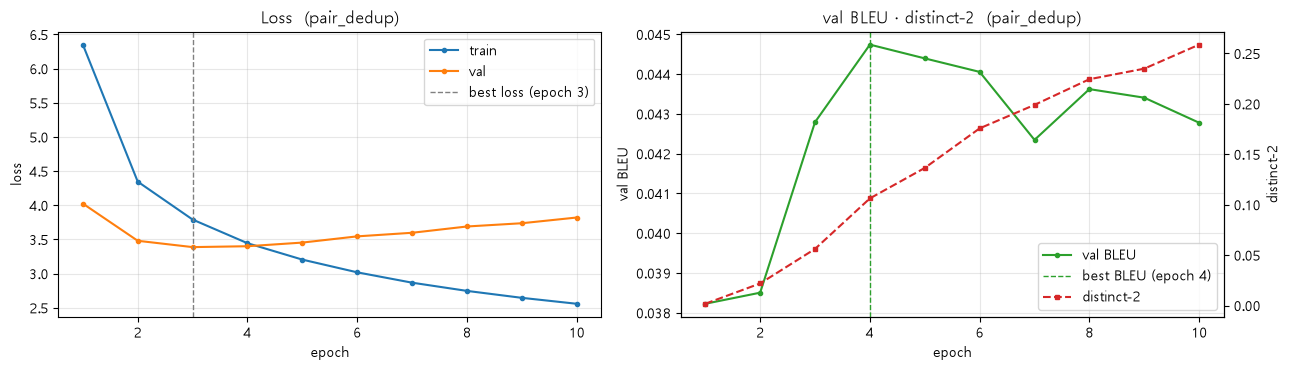

In [128]:
def plot_history(record):
    """왼쪽: train/val loss, 오른쪽: val BLEU · distinct-2."""
    h = record['history']
    epochs = [r['epoch'] for r in h]
    has_bleu = 'val_bleu' in h[0]
    fig, axes = plt.subplots(1, 2 if has_bleu else 1, figsize=(13 if has_bleu else 7, 3.8), squeeze=False)

    ax = axes[0, 0]
    ax.plot(epochs, [r['train_loss'] for r in h], 'o-', ms=3, label='train')
    ax.plot(epochs, [r['val_loss'] for r in h], 'o-', ms=3, label='val')
    ax.axvline(record['best_epoch'], color='gray', ls='--', lw=1, label=f"best loss (epoch {record['best_epoch']})")
    ax.set_title(f"Loss  ({record['name']})"); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
    ax.legend(); ax.grid(alpha=.3)

    if has_bleu:
        ax = axes[0, 1]
        ax.plot(epochs, [r['val_bleu'] for r in h], 'o-', ms=3, color='C2', label='val BLEU')
        ax.axvline(record['best_bleu_epoch'], color='C2', ls='--', lw=1,
                   label=f"best BLEU (epoch {record['best_bleu_epoch']})")
        ax.set_xlabel('epoch'); ax.set_ylabel('val BLEU'); ax.grid(alpha=.3)
        ax2 = ax.twinx()
        ax2.plot(epochs, [r['distinct_2'] for r in h], 's--', ms=3, color='C3', label='distinct-2')
        ax2.set_ylabel('distinct-2')
        (h1, l1), (h2, l2) = ax.get_legend_handles_labels(), ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc='lower right')
        ax.set_title(f"val BLEU · distinct-2  ({record['name']})")

    plt.tight_layout()
    return axes


plot_history(base_record)
plt.show()

### 9-2. epoch별 예문 답변

In [129]:
def answers_table(record):
    rows = []
    for h in record['history']:
        row = {'epoch': h['epoch'], 'train': round(h['train_loss'], 3), 'val': round(h['val_loss'], 3)}
        if 'val_bleu' in h:
            row.update({'bleu': round(h['val_bleu'], 4), 'dist-2': round(h['distinct_2'], 3)})
        row.update({f'Q{i + 1}': a for i, a in enumerate(h['answers'])})
        rows.append(row)
    return pd.DataFrame(rows).set_index('epoch')

pd.set_option('display.max_colwidth', 60)
answers_table(base_record)

,train,val,bleu,dist-2,Q1,Q2,Q3,Q4
epoch,,,,,,,,
1,6.352,4.025,0.0382,0.002,마음 이 있 어요 .,마음 이 이 있 어요 .,마음 이 이 있 어요 .,마음 이 이 있 어요 .
2,4.346,3.481,0.0385,0.022,좋 은 사람 이 에요 .,좋 은 시간 이 에요 .,잘 하 지 않 겠 네요 .,저 도 좋 은 사람 이 에요 .
3,3.791,3.388,0.0428,0.056,좋 은 곳 으로 가 보 세요 .,좋 은 생각 이 네요 .,좋 은 생각 이 네요 .,저 도 좋 은 곳 이 있 어요 .
4,3.445,3.401,0.0447,0.106,좋 은 곳 에 가 는 곳 이 좋 을 거 예요 .,피곤 한가 봐요 .,좋 은 곳 이 있 나 봐요 .,많이 지쳤 나 봐요 .
5,3.205,3.454,0.0444,0.136,운동 을 해 보 세요 .,좋 은 소식 이 네요 .,좋 은 곳 이 필요 하 겠 네요 .,마음 이 복잡 하 겠 어요 .
6,3.019,3.545,0.0441,0.176,좋 은 곳 으로 가 보 세요 .,피곤 했 나 봐요 .,데이트 를 해 보 세요 .,마음 이 복잡 하 겠 어요 .
7,2.867,3.598,0.0423,0.199,나중 에 없애 주 세요 .,피곤 했 나 봐요 .,득템 했 어요 .,마음 이 복잡 하 겠 어요 .
8,2.747,3.690,0.0436,0.224,같이 놀 아요 .,피곤 한가 봐요 .,득템 했 길 바라 요 .,내 집 마련 축하 해요 .
9,2.646,3.738,0.0434,0.235,마음 에 따라 얼마 든지 되 겠 네요 .,피곤 했 나 봐요 .,득템 했 길 바라 요 .,사랑 의 예의 가 없 네요 .


### 9-3. BLEU (greedy)

아래 `eval_bleu` 결과는 학습 기록에서 best(val loss) epoch의 `val_bleu`와 거의 같아야 한다(배치 greedy 구현 확인용).

In [130]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)


def eval_bleu_single(model, src_sentence, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    src_tokens = src_tokenizer.encode_as_ids(src_sentence)
    tgt_tokens = tgt_tokenizer.encode_as_ids(tgt_sentence)

    if (len(src_tokens) > MAX_LEN): return None
    if (len(tgt_tokens) > MAX_LEN): return None

    reference = tgt_sentence.split()
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split()

    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate)
        print("Real: ", reference)
        print("Score: %lf\n" % score)

    return score


def eval_bleu(model, src_sentences, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    total_score = 0.0
    count = 0

    for idx in tqdm(range(len(src_sentences))):
        score = eval_bleu_single(model, src_sentences[idx], tgt_sentence[idx], src_tokenizer, tgt_tokenizer, verbose)
        if score is None:  # 길이 초과로 평가에서 제외된 문장만 건너뜀 (0점은 포함)
            continue
        total_score += score
        count += 1

    print("Num of Sample:", count)
    print("Total Score:", total_score / count)
    return total_score / count


val_ref = [' '.join(a) for a in val_ans]   # 정답 : 형태소 공백 결합

# 몇 개만 자세히
for i in range(5):
    eval_bleu_single(transformer, val_que[i], val_ref[i], vocab, vocab)

Source Sentence:  ['썸', '타', '는', '여자', '만나', '기', '로', '했', '는데', '편하', '게', '입', '어도', '됨', '?']
Model Prediction:  ['썸', '을', '가지', '고', '싶', '으면', '좋', '겠', '어요', '.']
Real:  ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Score: 0.015223

Source Sentence:  ['썸녀', '만나', '는데', '뭐', '입', '지', '?']
Model Prediction:  ['좋', '은', '곳', '으로', '가', '좋', '을', '것', '같', '아요', '.']
Real:  ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Score: 0.032954

Source Sentence:  ['친구', '에게', '물', '어', '봐야', '겠', '다']
Model Prediction:  ['좋', '은', '친구', '가', '있', '을', '거', '예요', '.']
Real:  ['친구', '도', '잘', '몰라요', '.']
Score: 0.028518

Source Sentence:  ['친구', '한테', '물어봐야지']
Model Prediction:  ['친구', '가', '있', '으면', '좋', '겠', '네요', '.']
Real:  ['친구', '도', '잘', '몰라요', '.']
Score: 0.033032

Source Sentence:  ['사랑', '하', '는', '사람', '은', '딱', '알아볼', '수', '있', '어', '?']
Model Prediction:  ['사랑', '하', '고', '있', '을', '거', '예요', '.']
R

In [131]:
base_val_bleu = eval_bleu(transformer, val_que, val_ref, vocab, vocab, verbose=False)

  0%|          | 0/1160 [00:00<?, ?it/s]

Num of Sample: 1160
Total Score: 0.04279355194529767


### 9-4. Beam Search

In [132]:
@torch.no_grad()
def calc_prob(src_ids, tgt_ids, model):
    enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(src_ids, tgt_ids)
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src_ids, tgt_ids, enc_padding_mask, combined_mask, dec_padding_mask
    )
    return F.softmax(predictions, dim=-1)


@torch.no_grad()
def beam_search_decoder(sentence,
                        src_len,
                        tgt_len,
                        model,
                        src_tokenizer,
                        tgt_tokenizer,
                        beam_size):
    model.eval()
    bos, eos = tgt_tokenizer.bos_id(), tgt_tokenizer.eos_id()

    # src_in: [1, src_len] 크기의 텐서로 padding (0: 패딩 토큰)
    tokens = src_tokenizer.encode_as_ids(sentence)[:src_len]
    padded = np.zeros((1, src_len), dtype=np.int64)
    padded[0, :len(tokens)] = tokens
    src_in = torch.tensor(padded, dtype=torch.long, device=device)

    beams = [([bos], 0.0)]   # (토큰 시퀀스, 누적 log 확률)
    finished = []            # EOS로 끝난 후보

    for _ in range(tgt_len - 1):
        # 살아있는 beam들을 한 배치로 묶어 한 번에 계산
        dec_in = torch.tensor([seq for seq, _ in beams], dtype=torch.long, device=device)
        prob = calc_prob(src_in.expand(len(beams), -1), dec_in, model)[:, -1]  # [k, vocab]
        log_prob = prob.clamp_min(1e-12).log()  # 확률 곱 대신 log 합 -> underflow 방지

        # 각 beam에서 상위 beam_size개 후보 생성
        top_lp, top_id = log_prob.topk(beam_size, dim=-1)
        candidates = []
        for b, (seq, score) in enumerate(beams):
            for lp, idx in zip(top_lp[b].tolist(), top_id[b].tolist()):
                candidates.append((seq + [idx], score + lp))

        # 점수 순으로 살아남을 beam 선택, EOS로 끝난 후보는 따로 보관
        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = []
        for seq, score in candidates:
            if seq[-1] == eos:
                finished.append((seq, score))
            else:
                beams.append((seq, score))
            if len(beams) == beam_size:
                break

        if not beams:
            break

    # 길이 정규화 점수로 최종 순위 결정
    alpha = 0.7
    norm = lambda seq, score: score / (len(seq) - 1) ** alpha
    results = sorted(finished + beams, key=lambda x: norm(*x), reverse=True)[:beam_size]
    return [seq for seq, _ in results]


def beam_bleu(reference, ids, tokenizer):
    reference_tokens = reference.split()

    total_score = 0.0
    num_candidates = len(ids)
    if num_candidates == 0:
        return 0.0

    for candidate_ids in ids:
        candidate_sentence = tokenizer.decode_ids(candidate_ids)
        candidate_tokens = candidate_sentence.split()

        score = calculate_bleu(reference_tokens, candidate_tokens)

        print(f"Reference: {reference_tokens}")
        print(f"Candidate: {candidate_tokens}")
        print(f"BLEU: {score}")

        total_score += score

    return total_score / num_candidates


def answer_beam(sentence, model, beam_size=5):
    """원문 질문 -> beam search 1순위 답변"""
    ids = beam_search_decoder(sentence, MAX_LEN, DEC_LEN, model, vocab, vocab, beam_size)
    return vocab.decode_ids(ids[0])

In [133]:
# 인덱스를 바꿔가며 확인
test_idx = 0

ids = beam_search_decoder(val_que[test_idx], MAX_LEN, DEC_LEN, transformer, vocab, vocab, beam_size=5)
print('Question :', ' '.join(val_que[test_idx]))
bleu = beam_bleu(val_ref[test_idx], ids, vocab)
print(bleu)

Question : 썸 타 는 여자 만나 기 로 했 는데 편하 게 입 어도 됨 ?
Reference: ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Candidate: ['좋', '아', '하', '는', '게', '좋', '을', '것', '같', '아요', '.']
BLEU: 0.08154855185641265
Reference: ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Candidate: ['좋', '아', '하', '는', '것', '도', '좋', '을', '것', '같', '아요', '.']
BLEU: 0.03527481708639238
Reference: ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Candidate: ['좋', '아', '하', '는', '사람', '이', '좋', '을', '것', '같', '아요', '.']
BLEU: 0.033360862268577436
Reference: ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Candidate: ['좋', '아', '하', '는', '게', '좋', '을', '거', '같', '아요', '.']
BLEU: 0.08154855185641265
Reference: ['편한', '옷차림', '도', '괜찮', '지만', '어느', '정도', '격식', '은', '차리', '는', '게', '좋', '아요', '.']
Candidate: ['좋', '아', '하', '는', '것', '도', '좋', '을', '거', '같', '아요', '.']
BLEU: 0.

### 9-5. 예문 답변

주어진 예문 4개에 대해 greedy / beam(5) 답변을 비교한다.

In [134]:
def answer_report(model, sentences):
    rows = [{'질문': s, 'greedy': answer(s, model), 'beam(5)': answer_beam(s, model)} for s in sentences]
    return pd.DataFrame(rows)

answer_report(transformer, EXAMPLES)

,질문,greedy,beam(5)
0,"지루하다, 놀러가고 싶어.",좋 은 곳 으로 가 보 세요 .,좋 은 곳 으로 가 보 세요 .
1,오늘 일찍 일어났더니 피곤하다.,좋 은 생각 이 네요 .,축하 드려요 .
2,간만에 여자친구랑 데이트 하기로 했어.,좋 은 생각 이 네요 .,좋 아 하 는 게 좋 겠 네요 .
3,집에 있는다는 소리야.,저 도 좋 은 곳 이 있 어요 .,저 도 괜찮 아요 .


### 9-6. 챗봇과 대화하기 (best BLEU 체크포인트)

val BLEU 기준 best 가중치(`data/ckpt/<RUN_NAME>_bleu.pt`)를 불러와, 주어진 예문 4개에 먼저 답한 뒤 직접 입력한 질문에 답한다.
빈 줄이나 `q` 를 입력하면 대화가 종료된다.

In [137]:
chatbot, chatbot_record = load_run(RUN_NAME, 'bleu')   # val BLEU 기준 best 가중치
print(f"[{RUN_NAME}] val BLEU 기준 best : epoch {chatbot_record['best_bleu_epoch']} "
      f"| val BLEU {chatbot_record['best_bleu']:.4f}\n")

# 주어진 예문 (루브릭 3)
for q in EXAMPLES:
    print(f'나    > {q}')
    print(f'챗봇  > {answer(q, chatbot)}\n')


def chat(model):
    """질문을 입력하면 답한다. 빈 줄이나 'q' 를 입력하면 끝낸다."""
    while True:
        question = input('나    > ').strip()
        if question in ('', 'q', 'quit', '종료'):
            print('대화를 마칩니다.')
            break
        print(f'챗봇  > {answer(question, model)}\n')


chat(chatbot)

[pair_dedup] val BLEU 기준 best : epoch 4 | val BLEU 0.0447

나    > 지루하다, 놀러가고 싶어.
챗봇  > 좋 은 곳 에 가 는 곳 이 좋 을 거 예요 .

나    > 오늘 일찍 일어났더니 피곤하다.
챗봇  > 피곤 한가 봐요 .

나    > 간만에 여자친구랑 데이트 하기로 했어.
챗봇  > 좋 은 곳 이 있 나 봐요 .

나    > 집에 있는다는 소리야.
챗봇  > 많이 지쳤 나 봐요 .



나    >  배고프다


챗봇  > 시원 한 게 드세요 .



나    >  안녕


챗봇  > 안녕 하 세요 .



...

챗봇  > 저 도 늦 지 마세요 .



나    >  앉아 있으니까 허리가 아프다


챗봇  > 건강 에 솔직 한 게 관리 하 세요 .



나    >  q


대화를 마칩니다.


---
# 10. 결과 해석

최종 모델은 **Exp 4 `pair_dedup`의 val BLEU 기준 best 체크포인트(epoch 4)** 이다. 체크포인트는 val BLEU로 골랐다.

| 항목 | 결과 |
|---|---|
| 데이터 | 원본 11,823 → (Q, A) 쌍 중복 제거 11,590 → train 10,430 / val 1,160 (답변 단위 분할) → train 증강 **30,327** (원본 + LS(Q) + 오타(Q)) |
| 최종 하이퍼파라미터 | n_layers 1 · d_model 368 · n_heads 8 · d_ff 1024 · dropout 0.4 · label smoothing 0.1 · lr 배율 0.5 |
| best epoch / val loss | val loss 기준 epoch 3 / 3.388 · **최종(BLEU 기준) epoch 4 / 3.401** |
| val BLEU (greedy) | 0.0428 |
| 과적합 여부 | val loss는 epoch 3이 최저이고 이후 epoch당 평균 0.06씩 올라 epoch 10에 3.821이 된다. train loss는 계속 떨어지므로 epoch 4 이후는 과적합 구간이다.다 |

### 과적합을 줄인 과정 (루브릭 2)

| 단계 | 바꾼 것 | best val loss | best 이후 val loss 상승 (epoch당) |
|---|---|---|---|
| Exp 0 | 기준선 (dropout 0.2) | 3.590 | 0.29 |
| Exp 1 | dropout 0.4 | 3.577 | 0.16 |
| Exp 2 | + label smoothing 0.1 | 3.527 | 0.11 |
| Exp 3 | + lr 배율 0.5 | 3.488 | 0.08 |
| Exp 4 | + 데이터 변경 (쌍 기준 중복 제거 · 질문만 증강) | 3.388 * | 0.06 |

\* Exp 4는 val 세트가 달라 Exp 0~3과 수치를 직접 비교할 수 없다.

- 하이퍼파라미터(dropout · label smoothing · lr)는 과적합 속도를 0.29 → 0.08로 줄였지만 best val loss는 0.102만 낮췄다.
- 가장 큰 변화는 데이터에서 나왔다. 버려지던 실제 질문 약 4천 개를 되살리고 깨진 답변 증강을 뺀 것만으로 val loss가 Exp 0~3 누적 개선폭만큼 더 낮아졌다.

### 예문 답변

```
Translations
> 1. 지루하다, 놀러가고 싶어.             -> 좋 은 곳 에 가 는 곳 이 좋 을 거 예요 .
> 2. 오늘 일찍 일어났더니 피곤하다.       -> 피곤 한가 봐요 .
> 3. 간만에 여자친구랑 데이트 하기로 했어. -> 좋 은 곳 이 있 나 봐요 .
> 4. 집에 있는다는 소리야.                -> 많이 지쳤 나 봐요 .

Hyperparameters
> n_layers: 1
> d_model: 368
> n_heads: 8
> d_ff: 1024
> dropout: 0.4

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 4
```

추가 학습 설정: label smoothing 0.1 · lr 배율 0.5(최대 lr 8.2e-4) · 전체 10 epoch 중 val BLEU가 가장 높은 epoch 4 저장.

**직접 입력한 질문 (9-6)**

| 질문 | 답변 | 평가 |
|---|---|---|
| 배고프다 | 시원 한 게 드세요 . | 먹을 것을 권해 질문과 이어진다 |
| 안녕 | 안녕 하 세요 . | 적절하다 |
| 난 주말이 좋아 | 좋 은 곳 이 좋 아 하 는 것 도 좋 을 거 예요 . | 주제는 이어지지만 문장이 어색하다 |
| 뭐라는거야 | 저 도 모르 는 게 아니 에요 . | 뜻이 모호하다 |
| 넌 바보야 | 저 도 늦 지 마세요 . | 질문과 어긋난다 |
| 앉아 있으니까 허리가 아프다 | 건강 에 솔직 한 게 관리 하 세요 . | 건강 관리 주제는 맞지만 문장이 어색하다 |

- 예문 4개와 직접 입력한 질문 6개, 총 10개 중 `피곤 한가 봐요 .`, `안녕 하 세요 .`, `시원 한 게 드세요 .` 3개는 질문에 적절히 답했다. 4개는 주제는 이어지지만 문장이 어색하고, 3개는 질문과 어긋난다.
- 질문의 핵심어(피곤, 안녕, 건강)를 받아 답하는 경우는 잘 되지만, 문장 전체의 의미(데이트 약속, 집에 있겠다는 말)를 이해해야 하는 질문에는 `좋 은 곳 이 …` 같은 범용 답변으로 빠진다.

### 한계
- 모든 실험을 시드 1개로 돌려, 실험 간 작은 차이(0.01~0.05)가 잡음인지 확인하지 못했다.
- val loss 기준 best의 distinct-2가 0.056으로, 생성 답변의 다양성이 낮다.

---
# 11. 실험

- 기준선(`base`) 결과를 본 뒤 **한 번에 하나씩** 바꿔 가며 진행한다. 실험마다 이 섹션에 셀을 추가한다.

### 실험 기록

| # | 이름 | 바꾼 것 (기준선 대비) | best epoch | best val loss | val BLEU | 예문 답변 요약 | 결론 |
|---|---|---|---|---|---|---|---|
| 0 | base | - | 2 | 3.590 | 0.0369 | best는 반복·범용 답변, epoch 5가 더 그럴듯함 | epoch 3부터 과적합 |
| 1 | dropout_0.4 | dropout 0.2 → 0.4 | 2 | 3.577 | 0.0380 | best는 반복 없지만 범용 답변, epoch 8이 더 그럴듯함 | 과적합 속도 약 절반, 최고 성능은 동일 → 0.4 유지 |
| 2 | label_smoothing_0.1 | label smoothing 0 → 0.1 (Exp 1 기준) | 3 | 3.527 | 0.0376 | best의 범용 답변 쏠림 감소, epoch 9가 더 그럴듯함 | 과적합 더 완만, val loss 소폭 개선 → 0.1 유지 |
| 3 | lr_scale_0.5 | lr 배율 1.0 → 0.5 (Exp 2 기준) | 3 | 3.488 | 0.0399 | best greedy는 반복 없음·beam은 범용, epoch 10이 가장 그럴듯함 | 과적합 더 완만, val loss 소폭 개선 → 0.5 유지 |
| 4 | pair_dedup | 데이터: (Q, A) 쌍 중복 제거 · 답변 단위 분할 · 질문만 증강 (Exp 3 설정, val 세트 변경) | 3 (BLEU 기준 4) | 3.388 | 0.0428 (BLEU 기준 0.0447) | best loss는 범용 답변, best BLEU(epoch 4)는 Q2만 질문과 잘 맞음 | 직접 비교는 불가하나 모든 지표 개선 → 데이터 변경 유지 |

### Exp 0. `base`

**설정**: n_layers 1 · d_model 368 · n_heads 8 · d_ff 1024 · dropout 0.2 · warmup 1000 · batch 64 · 10 epoch · VOCAB_SIZE 6,000 · train 32,043 / val 756 · 파라미터 5.36M

**결과**

| epoch | 1 | 2 | 3 | 4 | 5 | 10 |
|---|---|---|---|---|---|---|
| train loss | 5.293 | 3.036 | 2.167 | 1.476 | 1.064 | 0.419 |
| val loss | 3.680 | **3.590** | 3.915 | 4.337 | 4.731 | 5.889 |

| 예문 | base (epoch 5) |
|---|---|
| 지루하다, 놀러가고 싶어. | 다른 곳 에 연락 을 해 보 세요 . |
| 오늘 일찍 일어났더니 피곤하다. | 이제 일어날 시간 이 에요 . |
| 간만에 여자친구랑 데이트 하기로 했어. | 필요 한 것 같 아요 . |
| 집에 있는다는 소리야. | 나쁜 생각 이 네요 . |


- best(epoch 2) 모델의 val BLEU(greedy)는 0.0369이다.
- best(epoch 2) 예문 답변: greedy는 `공부 하 고 하 고 하 세요 .`, `생각 은 은 미화 되 나 봐요 .`처럼 토큰이 반복된다. beam(5)는 `잘 하 고 있 을 거 예요 .`, `추억 이 되 나 봐요 .`, `생각 하 지 마세요 .`, `집 에 따라 다르 겠 네요 .`로 반복은 없지만 범용적이다.
- val 문장에서도 greedy 반복이 심하다: `좀 좀 좀 좀 좀`, `에서 에서 에서 에서`, `아직`만 20번(최대 길이까지 `<end>`를 내지 못함).
- epoch 5 답변은 Q1·Q2가 질문 내용(놀러가고 싶다, 일찍 일어났다)과 이어지지만, Q3는 범용 답변이고 Q4는 질문과 어긋난다.

**해석**
- **epoch 3부터 과적합이다.** train loss는 끝까지 떨어지는데(0.419) val loss는 epoch 2가 최저이고 그 뒤로 매 epoch 오른다(epoch 10: 5.889).
- val loss 최저 시점(epoch 2 끝)은 warmup이 끝나 lr이 최대(1.65e-3)에 도달한 시점과 겹친다. best 체크포인트는 아직 덜 학습된 상태라 greedy에서 반복이 나타난다.
- val loss와 답변 품질이 어긋난다. val loss가 더 높은 epoch 5가 더 그럴듯한 답을 낸다. 답이 여러 개일 수 있는 챗봇에서는 정답 1개 기준 loss가 품질을 온전히 반영하지 못한다.

### Exp 1. `dropout_0.4`

**설정**: base에서 **dropout만 0.2 → 0.4**로 바꿨다.

**결과**

| epoch | 1 | 2 | 3 | 4 | 5 | 10 |
|---|---|---|---|---|---|---|
| train loss | 5.322 | 3.337 | 2.768 | 2.324 | 1.990 | 1.134 |
| val loss | 3.804 | **3.577** | 3.590 | 3.749 | 3.961 | 4.854 |

| 예문 | dropout_0.4 (epoch 8) |
|---|---|
| 지루하다, 놀러가고 싶어. | 다른 사람 들 과 연락 을 해 보 세요 . |
| 오늘 일찍 일어났더니 피곤하다. | 타이밍 이 안 맞 았 나 봐요 . |
| 간만에 여자친구랑 데이트 하기로 했어. | 분위기 좋 은 데이트 하 세요 . |
| 집에 있는다는 소리야. | 내 가 되 기 힘들 죠 . |


- best(epoch 2) 모델의 val BLEU(greedy)는 0.0380이다.
- best(epoch 2) 예문 답변: greedy는 `좋 은 사람 이 에요 .`, `저 도 좋 은 사람 이 에요 .`처럼 반복은 없지만 4문장 중 2개가 같은 범용 답변이다. beam(5)는 `연락 해 보 세요 .`, `괜찮 은 일 이 에요 .`, `좋 은 사람 이 에요 .`, `저 도 마음 이 었 나 봐요 .`이다.
- val 문장 5개의 greedy 답변에는 base에서 보였던 토큰 반복이 없다: `이별 은 항상 힘들 죠 .`, `힘든 시간 이 었 을 거 라 생각 해요 .`
- epoch 8(train 1.372 / val 4.500) 답변은 Q1·Q3가 질문 내용(놀러가고 싶다, 데이트)과 이어진다. Q2는 질문과 직접 이어지지 않고, Q4는 질문과 어긋나며 문장도 어색하다.

**해석**
- **과적합이 늦춰지고 완만해졌지만 사라지지는 않았다.** best 이후 val loss가 epoch당 평균 0.16씩 오른다(base 0.29). epoch 3의 val loss 3.590은 best와 거의 같고(base 3.915), epoch 10 val loss는 5.889 → 4.854로 낮아졌다. train loss도 epoch 10에서 0.419 → 1.134로 덜 떨어져 암기가 늦어졌다. 그래도 epoch 3부터 val loss는 계속 오른다.
- **최고 성능은 사실상 그대로다.** best val loss 3.590 → 3.577, val BLEU 0.0369 → 0.0380의 차이는 시드 1개로 본 결과라 잡음과 구분하기 어렵다. 성능이 떨어지지는 않았지만 올랐다고 보기도 어렵다.
- best 체크포인트에서 greedy 토큰 반복은 사라졌지만, 대신 `좋 은 사람 이 에요 .` 같은 범용 답변으로 모인다.
- 과적합이 느려진 만큼 val loss가 크게 오르기 전에 그럴듯한 답이 나온다. epoch 8의 val loss(4.500)는 base epoch 5(4.731)보다 낮다.
- **결론: dropout 0.4를 유지한다.** 성능 손해 없이 과적합 속도를 약 절반으로 줄였고, best 체크포인트의 반복도 없어졌다.

### Exp 2. `label_smoothing_0.1`

**설정**: Exp 1(dropout 0.4)에서 **label smoothing만 0 → 0.1**로 바꿨다. val loss는 smoothing 없이 계산해 이전 실험과 같은 기준이다.

**결과**

| epoch | 1 | 2 | 3 | 4 | 5 | 10 |
|---|---|---|---|---|---|---|
| train loss | 5.897 | 4.150 | 3.659 | 3.294 | 3.031 | 2.360 |
| val loss | 3.787 | 3.527 | **3.527** | 3.647 | 3.782 | 4.293 |

| 예문 | label_smoothing_0.1 (epoch 9) |
|---|---|
| 지루하다, 놀러가고 싶어. | 다른 곳 으로 관심 해 보 세요 . |
| 오늘 일찍 일어났더니 피곤하다. | 이제 일어날 시간 이 에요 . |
| 간만에 여자친구랑 데이트 하기로 했어. | 휴식 도 필요 하 죠 . |
| 집에 있는다는 소리야. | 집 에 있 죠 . |


- best(epoch 3) 모델의 val BLEU(greedy)는 0.0376이다.
- best(epoch 3) 예문 답변: greedy는 `같이 같이 운동 해 보 세요 .`, `짝사랑 이 에요 .`, `건강 에 좋 은 데이트 좋 아요 .`, `저 도 좋 아 하 는 거 예요 .`로 4문장이 모두 다르다. Exp 1 best에서 반복되던 `좋 은 사람 이 에요 .`는 없지만 `같이 같이`처럼 짧은 반복이 남아 있다. beam(5)는 `좋 은 사람 만날 수 있 을 거 예요 .`, `잠 이 에요 .`, `건강 에 좋 아요 .`, `즐거운 시간 이 네요 .`이다.
- val 문장 5개의 greedy 답변은 질문의 핵심어와 이어지는 경우가 늘었다: `이별 하 려다 붙잡 고 다시 사귀 는데` → `다시 연락 하 세요 .`, `몇 년 째 이별 인지` → `이별 에 는 면역 이 었 나 봐요 .`
- epoch 9(train 2.446 / val 4.180) 답변은 Q2가 질문(일찍 일어났다)과 이어지고, 이 답은 epoch 5~10 동안 거의 그대로 유지된다. Q1은 내용은 이어지지만 `관심 해`가 어색하고, Q3는 데이트와 이어지지 않으며, Q4는 질문의 `집`을 되풀이하는 수준이다.

**해석**
- **과적합이 더 완만해졌지만 사라지지는 않았다.** best 이후 val loss가 epoch당 평균 0.11씩 오른다(Exp 1 0.16, base 0.29). epoch 5 val loss는 3.961 → 3.782, epoch 10은 4.854 → 4.293으로 낮아졌다. 그래도 epoch 4부터 val loss는 계속 오른다.
- **최고 성능은 소폭 좋아졌다.** best val loss가 3.577 → 3.527로 0.050 낮아졌다. Exp 0 → 1의 차이(0.013)보다 크지만 시드 1개로 본 결과다. val BLEU는 0.0380 → 0.0376으로 차이가 없다.
- best 체크포인트가 범용 답변 하나로 모이는 현상이 줄었다. 정답 하나에 확률을 몰아주지 않도록 학습한 효과로 보인다.
- **결론: label smoothing 0.1을 유지한다.** 성능 손해 없이 과적합 속도를 더 줄였고, best 체크포인트의 범용 답변 쏠림도 줄었다. best가 lr 최대 시점에 묶여 있으므로 다음은 lr 조정을 실험한다.

### Exp 3. `lr_scale_0.5`

**설정**: Exp 2(dropout 0.4, label smoothing 0.1)에서 **lr 배율만 1.0 → 0.5**로 바꿨다. warmup 1000 스케줄은 그대로이고 최대 lr이 1.65e-3 → 8.2e-4로 낮아진다.

**결과**

| epoch | 1 | 2 | 3 | 4 | 5 | 10 |
|---|---|---|---|---|---|---|
| train loss | 6.356 | 4.406 | 3.882 | 3.538 | 3.288 | 2.588 |
| val loss | 4.051 | 3.559 | **3.488** | 3.529 | 3.644 | 4.059 |

| 예문 | lr_scale_0.5 (epoch 10) |
|---|---|
| 지루하다, 놀러가고 싶어. | 여행 은 항상 좋 죠 . |
| 오늘 일찍 일어났더니 피곤하다. | 이제 일어날 때 예요 . |
| 간만에 여자친구랑 데이트 하기로 했어. | 좋 은 곳 으로 가 보 세요 . |
| 집에 있는다는 소리야. | 내 맘 같 기 싫 죠 . |


- best(epoch 3) 모델의 val BLEU(greedy)는 0.0399이다.
- best(epoch 3) 예문 답변: greedy는 `좋 은 곳 으로 연락 해 보 세요 .`, `술 이 웬수 네요 .`, `좋 은 선택 이 에요 .`, `시간 이 필요 하 죠 .`로 4문장이 모두 다르고 Exp 2에 남아 있던 `같이 같이` 같은 반복도 없다. beam(5)는 `좋 은 곳 으로 연락 해 보 세요 .`, `좋 은 사람 이 에요 .`, `좋 아 하 세요 .`, `좋 은 사람 이 에요 .`로 4문장 중 2개가 같은 범용 답변이다.
- val 문장 5개의 greedy 답변에도 반복은 없다. `이별 하 려다 붙잡 고 다시 사귀 는데` → `이별 에 대한 말 해 보 세요 .`, `몇 년 째 이별 인지` → `힘든 시간 이 었 을 거 예요 .`처럼 이어지는 답도 있지만, `정말 숨 막혀` → `따뜻 한 잔 !`처럼 질문과 무관한 답도 있다.
- epoch 10(train 2.588 / val 4.059) 답변은 Q1(놀러가고 싶다 → 여행), Q2(일찍 일어났다 → 일어날 때), Q3(데이트 → 좋은 곳으로 가 보세요)가 질문과 이어진다. Q4는 질문과 어긋나고 문장도 어색하다.

**해석**
- **과적합이 더 완만해졌지만 사라지지는 않았다.** best 이후 val loss가 epoch당 평균 0.08씩 오른다(Exp 2 0.11, Exp 1 0.16, base 0.29). epoch 5 val loss는 3.782 → 3.644, epoch 10은 4.293 → 4.059로 낮아졌다. 그래도 epoch 4부터 val loss는 계속 오른다.
- **최고 성능은 소폭 좋아졌다.** best val loss가 3.527 → 3.488로 0.039 낮아졌고, val BLEU는 0.0376 → 0.0399이다. 둘 다 시드 1개로 본 작은 차이다. base부터 누적하면 best val loss는 3.590 → 3.488로 0.102 낮아졌다.
- lr을 절반으로 줄여도 epoch 3에서 val loss가 최저가 되고 이후 오르므로, 10 epoch 안에서 학습이 덜 된 상태는 아니다.
- lr을 절반으로 줄였지만 best epoch는 Exp 2와 같은 3이다. 과적합 시점이 lr 크기보다 같은 데이터를 반복해 보는 횟수(1 epoch에 원본을 약 4.7번 봄)에 더 좌우되는 것으로 보인다.
- **결론: lr 배율 0.5를 유지한다.** 성능 손해 없이 과적합 속도를 더 줄였고, best greedy 답변의 반복도 없어졌으며, epoch 10 예문 4개 중 3개가 질문과 이어진다.

### Exp 4. `pair_dedup`

**설정**: Exp 3 설정(dropout 0.4, label smoothing 0.1, lr 배율 0.5)은 그대로 두고 **데이터만** 바꿨다. (Q, A) 쌍 기준 중복 제거 · 답변 단위 train/val 분할 · 질문만 증강(LS(Q)는 상위 3개 후보 중 무작위, 오타(Q)). 쌍 수 11,590 → train 10,430 / val 1,160 → 증강 30,327(×2.91). val 세트가 달라져 Exp 0~3과 수치를 직접 비교할 수 없다.

**결과**

| epoch | 1 | 2 | 3 | 4 | 5 | 10 |
|---|---|---|---|---|---|---|
| train loss | 6.352 | 4.346 | 3.791 | 3.445 | 3.205 | 2.559 |
| val loss | 4.025 | 3.481 | **3.388** | 3.401 | 3.454 | 3.821 |
| val BLEU | 0.0382 | 0.0385 | 0.0428 | **0.0447** | 0.0444 | 0.0428 |
| distinct-2 | 0.002 | 0.022 | 0.056 | 0.106 | 0.136 | 0.259 |

| 예문 | pair_dedup (best BLEU, epoch 4) |
|---|---|
| 지루하다, 놀러가고 싶어. | 좋 은 곳 에 가 는 곳 이 좋 을 거 예요 . |
| 오늘 일찍 일어났더니 피곤하다. | 피곤 한가 봐요 . |
| 간만에 여자친구랑 데이트 하기로 했어. | 좋 은 곳 이 있 나 봐요 . |
| 집에 있는다는 소리야. | 많이 지쳤 나 봐요 . |


- best(val loss, epoch 3) 모델의 val BLEU(greedy)는 0.0428이다. 9-3 `eval_bleu` 결과(0.04279)가 학습 기록의 epoch 3 `val_bleu`(0.04279)와 같아, epoch마다 계산한 val BLEU가 `eval_bleu`와 같은 값임을 확인했다.
- best(val loss, epoch 3) 예문 답변: greedy는 `좋 은 곳 으로 가 보 세요 .`, `좋 은 생각 이 네요 .`, `좋 은 생각 이 네요 .`, `저 도 좋 은 곳 이 있 어요 .`로 4문장 중 2개가 같고 모두 범용적이다. beam(5)는 `좋 은 곳 으로 가 보 세요 .`, `축하 드려요 .`, `좋 아 하 는 게 좋 겠 네요 .`, `저 도 괜찮 아요 .`이다.
- val 문장 5개의 greedy 답변에는 반복이 없지만, 질문의 단어를 되풀이하는 범용 답변이 많다: `친구 한테 물어봐야지` → `친구 가 있 으면 좋 겠 네요 .`, `사랑 하 는 사람 은 딱 알아볼 수 있 어 ?` → `사랑 하 고 있 을 거 예요 .`
- best(val loss) epoch 3의 distinct-2가 0.056으로 낮다. 생성한 val 답변 대부분이 같은 표현을 쓴다는 뜻이다. distinct-2는 epoch마다 올라 epoch 10에 0.259가 된다.
- best BLEU(epoch 4, val loss 3.401) 답변은 Q2(피곤하다 → 피곤한가 봐요)가 질문과 맞는다. Q1은 놀러가는 내용과 이어지지만 `곳 에 가 는 곳 이`처럼 문장이 어색하고, Q3는 데이트와 이어지지 않는 범용 답변이며, Q4는 적절한 답변이다.

**해석**
- **val 세트가 달라 Exp 3과 직접 비교할 수 없다.** 두 val 모두 train에 없는 답변으로만 구성돼 성격은 같다. 그 전제에서 best val loss는 3.488 → 3.388(−0.100), val BLEU는 0.0399 → 0.0428(BLEU 기준 체크포인트 0.0447)로 모든 지표가 좋아졌다. val loss 차이는 Exp 0 → 3의 누적 변화(0.102)와 비슷한 크기다.
- **과적합이 더 완만하다.** best 이후 val loss가 epoch당 평균 0.06씩 오른다(Exp 3 0.08). 원본 쌍이 6,811 → 10,430으로 늘고, 1 epoch에 원본을 보는 횟수는 약 4.7번 → 2.9번으로 줄었다.
- **val loss와 val BLEU의 best가 한 epoch 차이다.** val loss는 epoch 3, BLEU는 epoch 4가 최고이고, BLEU는 epoch 4~6 동안 0.044 안팎을 유지한다. 두 체크포인트의 val loss 차이는 0.013으로 작다.
- **뒤 epoch 답변은 더 다양해지지만 정답에 더 가까워지지는 않는다.** epoch 10의 BLEU(0.0428)는 epoch 4(0.0447)보다 낮은데 distinct-2는 0.106 → 0.259로 오른다. Exp 0~3에서 뒤 epoch 답변이 더 그럴듯해 보였던 것도 다양성 때문이었을 가능성이 있다.
- **결론: 데이터 변경을 유지한다.** val loss·BLEU·과적합 속도가 모두 좋아졌다. best 체크포인트의 답변이 범용적이고 다양성이 낮은 것(epoch 3 distinct-2 0.056)은 남은 문제다.



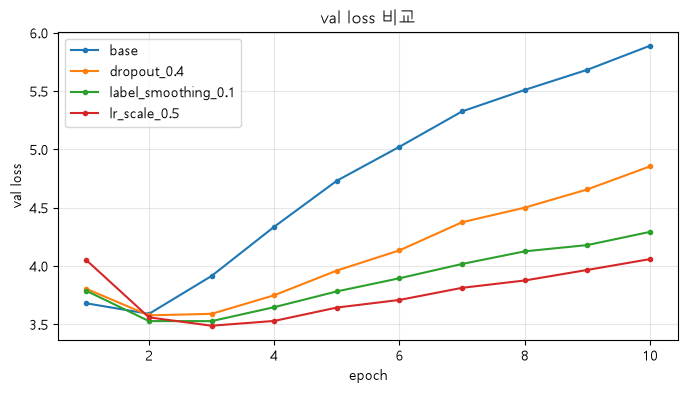

,name,n_train,n_val,best_epoch,best_val_loss,best_bleu_epoch,best_bleu,minutes
0,base,32043,None,2,3.5895,None,None,2.4
1,dropout_0.4,32043,None,2,3.5766,None,None,2.4
2,label_smoothing_0.1,32043,None,3,3.5271,None,None,2.5
3,lr_scale_0.5,32043,None,3,3.4878,None,None,2.5


In [138]:
def compare_runs(names):
    """저장된 실험 기록을 불러와 val loss 곡선과 요약 표를 함께 보여준다."""
    records = []
    for name in names:
        with open(os.path.join(HIST_DIR, f'{name}.json'), encoding='utf-8') as f:
            records.append(json.load(f))

    fig, ax = plt.subplots(figsize=(8, 4))
    for r in records:
        ax.plot([h['epoch'] for h in r['history']], [h['val_loss'] for h in r['history']],
                'o-', ms=3, label=r['name'])
    ax.set_title('val loss 비교'); ax.set_xlabel('epoch'); ax.set_ylabel('val loss')
    ax.legend(); ax.grid(alpha=.3)
    plt.show()

    return pd.DataFrame([{'name': r['name'], 'n_train': r['n_train'], 'n_val': r.get('n_val'),
                          'best_epoch': r['best_epoch'], 'best_val_loss': round(r['best_val_loss'], 4),
                          'best_bleu_epoch': r.get('best_bleu_epoch'),
                          'best_bleu': round(r['best_bleu'], 4) if 'best_bleu' in r else None,
                          'minutes': round(r['elapsed_sec'] / 60, 1)} for r in records])


# val 세트가 같은 실험끼리만 비교한다.
# Exp 0~3(Q/A 각각 중복 제거)과 Exp 4 이후(쌍 기준 · 답변 단위 분할)는 val 이 달라 비교할 수 없다.
compare_runs(['base', 'dropout_0.4', 'label_smoothing_0.1', 'lr_scale_0.5'])

---
# 12. 회고

### 배운 점 / 느낀 점
- 모델보다 데이터가 성능을 더 크게 좌우한다는 것을 실감했다. dropout·label smoothing·lr을 조정한 실험 3번으로 val loss가 0.102 낮아졌는데, 중복 제거 규칙을 바꿔 버려지던 질문 약 4천 개를 되살린 것만으로 비슷한 폭(0.100)이 더 낮아졌다.
- Word2Vec 유사어로 단어를 바꾸는 Lexical Substitution과 오타 노이즈를 만들었고, 답변(디코더 정답)을 증강하면 깨진 문장을 그대로 학습하므로 질문 쪽만 증강해야 성능이 더 좋다는 것도 알게되었다.
- 실험마다 한 가지만 바꾸고 결과를 기록하니 무엇이 효과가 있었는지 구분할 수 있었다. 기록을 비교하면서 dropout·label smoothing·lr은 과적합이 진행되는 속도만 늦췄을 뿐 최고 성능은 거의 올리지 못했다는 것을 확인했다.
- BLEU 점수를 올리기는 어려웠다. 챗봇은 한 질문에 맞는 답이 여러 개인데 BLEU는 정답 하나와의 일치만 봐서, 모든 실험이 0.04 안팎에 머물렀다. 그래서 val loss, BLEU, 답변 다양성(distinct-2), 예문 답변을 함께 보고 판단해야 한다는 것을 배웠다.

### 한계
- 과적합을 완전히 해결하지 못했다. 모든 실험에서 epoch 2~3 이후 val loss가 다시 올랐고, best 체크포인트를 저장해 과적합 전 모델을 쓰는 데 그쳤다.
- 데이터 증강에 시간을 더 들여 좋은 데이터셋을 만들었으면 좋았을 것 같다. 지금의 증강은 단어 하나를 바꾸거나 오타를 넣는 수준이라 새로운 정보를 거의 더하지 못했다.